In [5]:
import torch
import torch.nn as nn
import pickle
import numpy as np
import torchvision
from torchvision.models import vgg11, ResNet50_Weights, resnet50
import matplotlib.pyplot as plt
from torch.utils.flop_counter import FlopCounterMode
from typing import Union, Tuple
import os
from mpl_toolkits import axes_grid1
import plotly.graph_objects as go
import plotly.colors as pc
from utils import is_cnn_layer
import pickle

In [28]:
dataset = "cifar100"
model_name = "resnet50"
num_epochs = 160
experiment_one = "mambafrz_20_conv_seed_25_experiment_same_seed_reference"
experiment_two = "mambafrz_20_conv_seed_25_experiment_same_seed_reference/threshold_on_mambafrz_logits"
experiment_one_seed = 8487
experiment_two_seed = 8487
experiment_one_device = "cuda:0"
experiment_two_device = "cuda:0"
number_of_cnn_layers = 53
experiment_two_name = "SmartFRZ"
# experiment_two_name = "MambaFRZ"

In [29]:
# First look at CKA values across epochs heatmap
def add_colorbar(im, aspect=10, pad_fraction=0.5, **kwargs):
    """Add a vertical color bar to an image plot."""
    divider = axes_grid1.make_axes_locatable(im.axes)
    width = axes_grid1.axes_size.AxesY(im.axes, aspect=1./aspect)
    pad = axes_grid1.axes_size.Fraction(pad_fraction, width)
    current_ax = plt.gca()
    cax = divider.append_axes("right", size=width, pad=pad)
    plt.sca(current_ax)
    return im.axes.figure.colorbar(im, cax=cax, **kwargs)

def plot_results(
          cka_mini_batch_vector,
          save_path: str = None,
          title: str = None
          ):
        fig, ax = plt.subplots()

        reshaped_cka_mini_batch_vector = cka_mini_batch_vector.T
        im = ax.imshow(reshaped_cka_mini_batch_vector, origin='lower', cmap='magma')

        if title is not None:
            ax.set_title(f"{title}", fontsize=18)
        else:
            ax.set_title("Similarity to Fully Trained Model over Time", fontsize=18)

        # Set axis labels
        ax.set_ylabel("CNN Layer Index", fontsize=14)
        ax.set_xlabel("Epochs", fontsize=14)

        add_colorbar(im)

        if save_path is not None:
            plt.savefig(save_path, dpi=1000)

        plt.show()

In [30]:
def plot_cka_over_time(cka_over_time_file):
    with open(cka_over_time_file, 'rb') as f:
        cka_over_time = pickle.load(f)
    # print(cka_over_time)
    list_of_layers = list(cka_over_time.keys())
    print(f"List of Layers: {list_of_layers}")
    max_epochs = max(len(cka_over_time[key]) for key in list(cka_over_time.keys()))
    max_layers = len(list_of_layers)
    cka_matrix = torch.zeros((max_layers, max_epochs))
    for layer_index, layer in enumerate(list_of_layers):
        max_epochs_trained_for_layer = len(cka_over_time[layer])
        for epoch in range(max_epochs_trained_for_layer):
            cka_matrix[layer_index][epoch] = cka_over_time[layer][epoch]
    cka_matrix = cka_matrix.T
    plot_results(cka_matrix)

List of Layers: ['conv1', 'layer1.0.conv2', 'layer1.1.conv1', 'layer1.2.conv1', 'layer1.2.conv3', 'layer2.0.conv3', 'layer2.1.conv2', 'layer2.2.conv2', 'layer2.3.conv1', 'layer3.0.conv1', 'layer3.0.downsample.0', 'layer3.1.conv3', 'layer3.2.conv2', 'layer3.3.conv2', 'layer3.4.conv2', 'layer3.5.conv2', 'layer4.0.conv1', 'layer4.0.downsample.0', 'layer4.1.conv3', 'layer4.2.conv3']


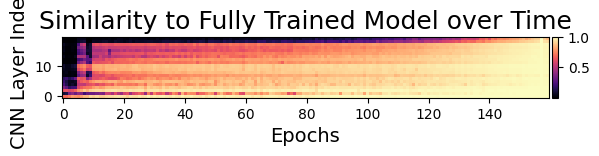

In [31]:
plot_cka_over_time(f"{experiment_one}/seed_{experiment_one_seed}/resnet50_cka_values_across_epochs.pkl")

List of Layers: ['conv1', 'layer1.0.conv1', 'layer1.0.conv2', 'layer1.0.conv3', 'layer1.0.downsample.0', 'layer1.1.conv1', 'layer1.1.conv2', 'layer1.1.conv3', 'layer1.2.conv1', 'layer1.2.conv2', 'layer1.2.conv3', 'layer2.0.conv1', 'layer2.0.conv2', 'layer2.0.conv3', 'layer2.0.downsample.0', 'layer2.1.conv1', 'layer2.1.conv2', 'layer2.1.conv3', 'layer2.2.conv1', 'layer2.2.conv2', 'layer2.2.conv3', 'layer2.3.conv1', 'layer2.3.conv2', 'layer2.3.conv3', 'layer3.0.conv1', 'layer3.0.conv2', 'layer3.0.conv3', 'layer3.0.downsample.0', 'layer3.1.conv1', 'layer3.1.conv2', 'layer3.1.conv3', 'layer3.2.conv1', 'layer3.2.conv2', 'layer3.2.conv3', 'layer3.3.conv1', 'layer3.3.conv2', 'layer3.3.conv3', 'layer3.4.conv1', 'layer3.4.conv2', 'layer3.4.conv3', 'layer3.5.conv1', 'layer3.5.conv2', 'layer3.5.conv3', 'layer4.0.conv1', 'layer4.0.conv2', 'layer4.0.conv3', 'layer4.0.downsample.0', 'layer4.1.conv1', 'layer4.1.conv2', 'layer4.1.conv3', 'layer4.2.conv1', 'layer4.2.conv2', 'layer4.2.conv3']


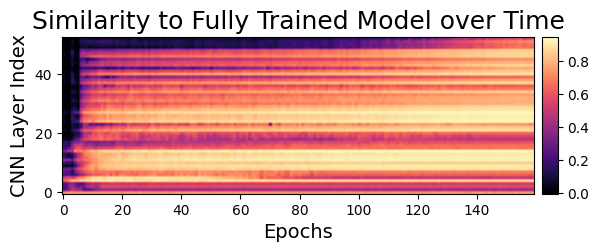

In [32]:
plot_cka_over_time(f"{experiment_two}/seed_{experiment_two_seed}/resnet50_cka_values_across_epochs.pkl")

In [33]:
def plot_accuracy_of_full_vs_similarity_guided_training_metrics(full_training_file, similarity_guided_training_file):
    with open(full_training_file, 'rb') as f:
        full_training = pickle.load(f)
    with open(similarity_guided_training_file, 'rb') as f:
        similarity_guided_training = pickle.load(f)

    acc_full, train_loss_full, test_loss_full = full_training
    acc_sim, train_loss_sim, test_loss_sim = similarity_guided_training

    epochs = list(range(1, len(acc_full) + 1))

    for index, (acc1, acc2) in enumerate(zip(acc_full, acc_sim)):
        acc_full[index] = acc1 * 100.0
        acc_sim[index] = acc2 * 100.0
    print(f"Max Accuracy Full Training: {max(acc_full)}")
    print(f"Max Accuracy Similarity-Guided Training: {max(acc_sim)}")
    # Plot Accuracy
    plt.figure(figsize=(10, 4))
    plt.plot(epochs, acc_full, label='End-to-End Accuracy')
    plt.plot(epochs, acc_sim, label='MambaFRZ Accuracy')
    print(acc_full)
    print(acc_sim)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot Training Loss
    plt.figure(figsize=(10, 4))
    plt.plot(epochs, train_loss_full, label='End-to-End Training Loss')
    plt.plot(epochs, train_loss_sim, label='MambaFRZ Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Training Loss')
    plt.title('Training Loss over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot Validation Loss
    plt.figure(figsize=(10, 4))
    plt.plot(epochs, test_loss_full, label=f'End-to-End Testing Loss')
    plt.plot(epochs, test_loss_sim, label=f'MambaFRZ Testing Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Validation Loss')
    plt.title('Validation Loss over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()

Max Accuracy Full Training: 82.66
Max Accuracy Similarity-Guided Training: 81.42
[2.6100000000000003, 4.74, 6.5600000000000005, 8.89, 11.27, 14.41, 18.44, 23.02, 24.75, 22.99, 24.94, 29.799999999999997, 33.29, 34.64, 40.44, 33.52, 31.78, 39.910000000000004, 41.64, 35.69, 39.42, 37.03, 42.99, 40.910000000000004, 41.620000000000005, 40.06, 42.25, 34.03, 36.88, 47.14, 45.09, 43.81, 44.769999999999996, 47.03, 41.75, 44.43, 46.32, 47.57, 46.54, 46.22, 43.3, 49.95, 42.970000000000006, 50.760000000000005, 41.19, 48.71, 52.559999999999995, 46.85, 49.91, 51.849999999999994, 50.470000000000006, 50.44, 49.830000000000005, 52.56999999999999, 53.290000000000006, 53.39, 46.75, 54.2, 52.92, 47.86, 55.14, 54.879999999999995, 48.230000000000004, 54.269999999999996, 56.89999999999999, 55.45, 50.080000000000005, 50.44, 57.06, 53.879999999999995, 54.05, 52.449999999999996, 54.279999999999994, 58.69, 53.559999999999995, 55.02, 55.97, 58.29, 58.64, 58.76, 60.050000000000004, 57.64, 61.419999999999995, 61.0,

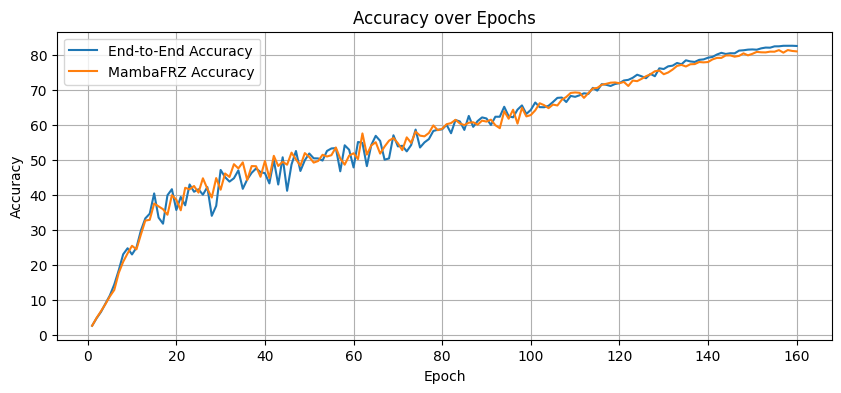

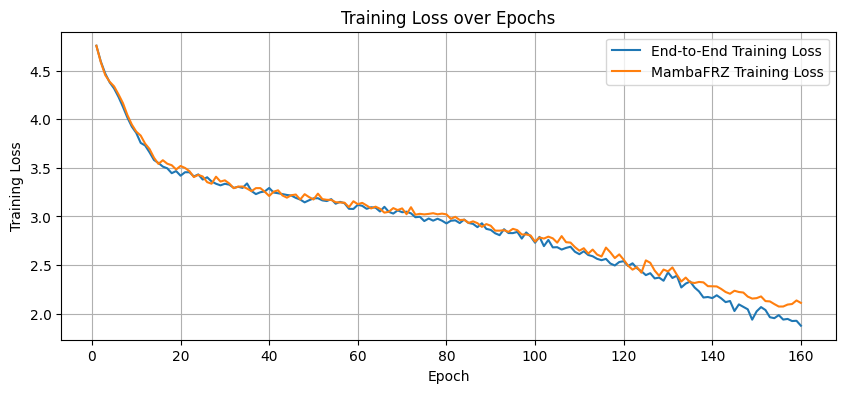

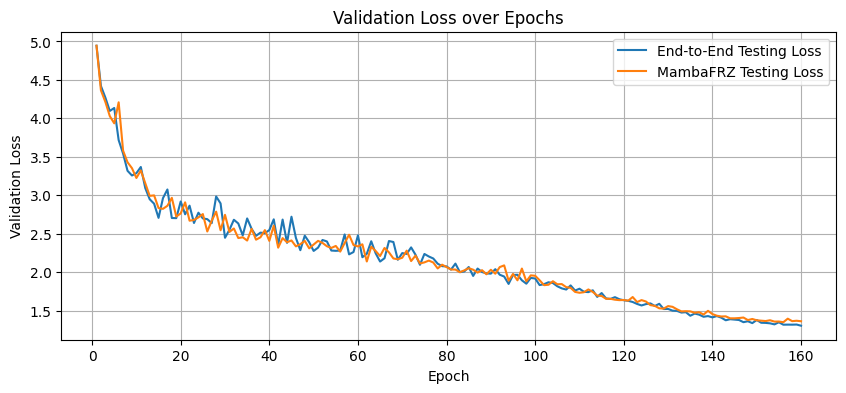

In [34]:
plot_accuracy_of_full_vs_similarity_guided_training_metrics(f"{experiment_one}/seed_{experiment_one_seed}/fully_trained_reference_model_resnet50_metrics.pkl", f"{experiment_two}/seed_{experiment_two_seed}/fully_trained_reference_model_resnet50_metrics.pkl")

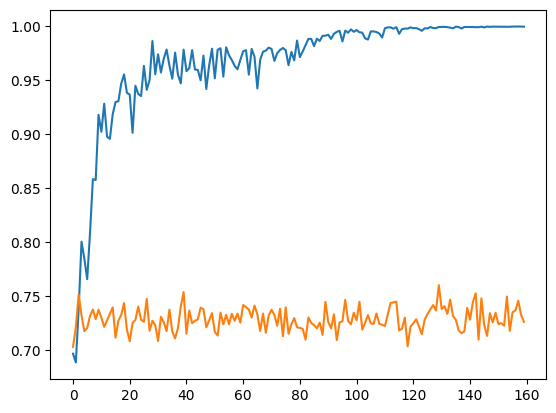

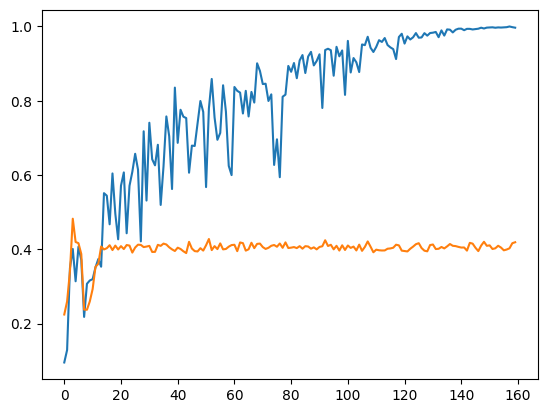

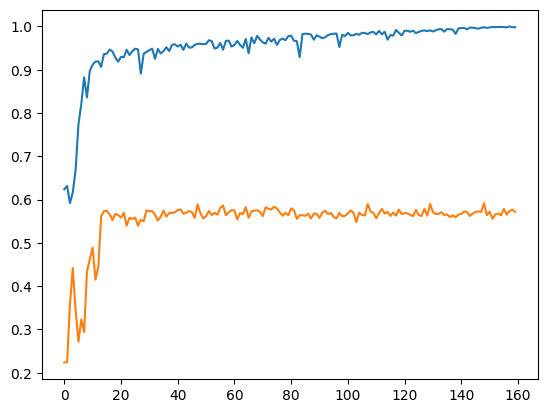

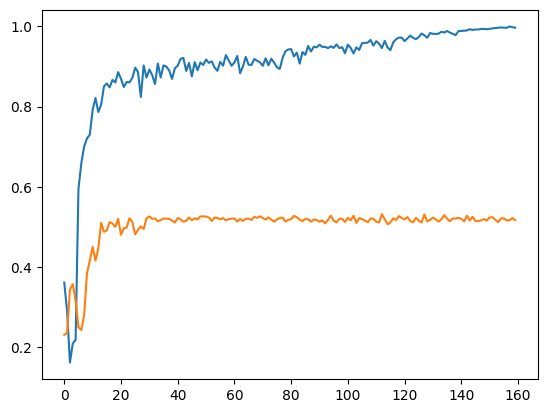

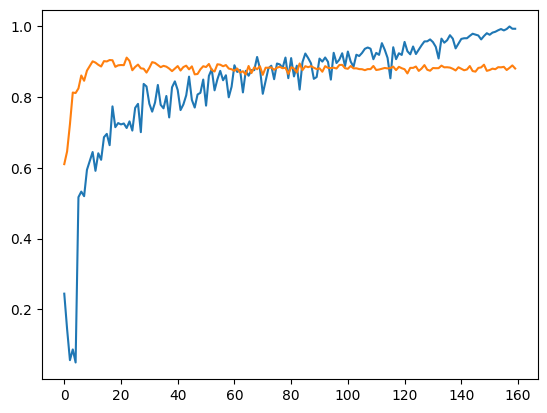

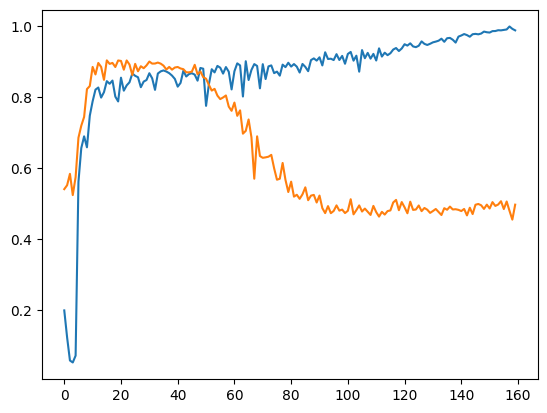

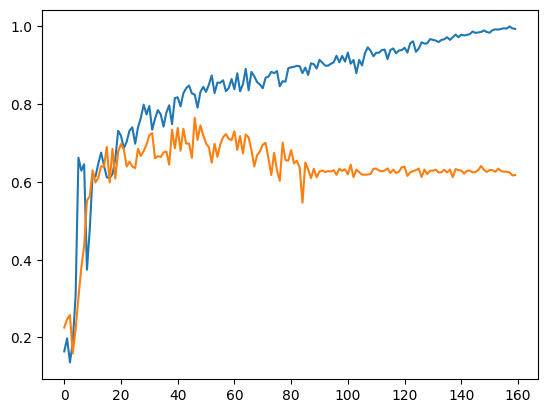

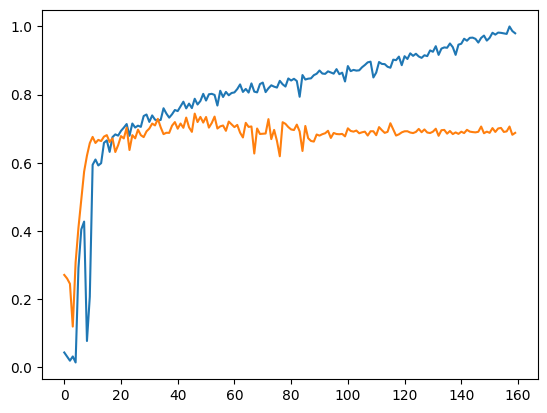

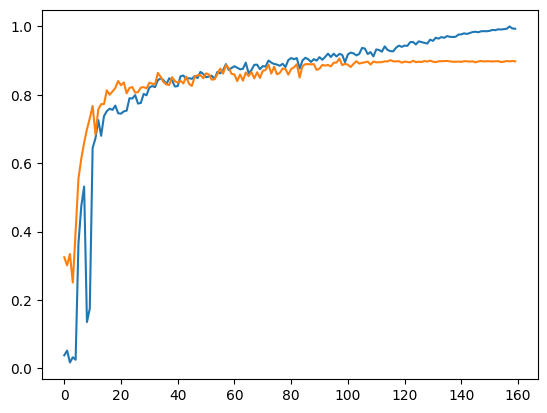

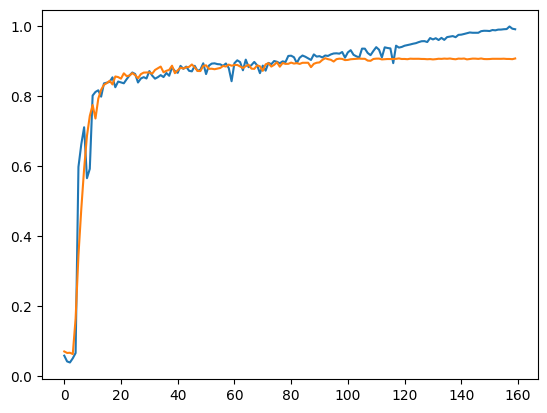

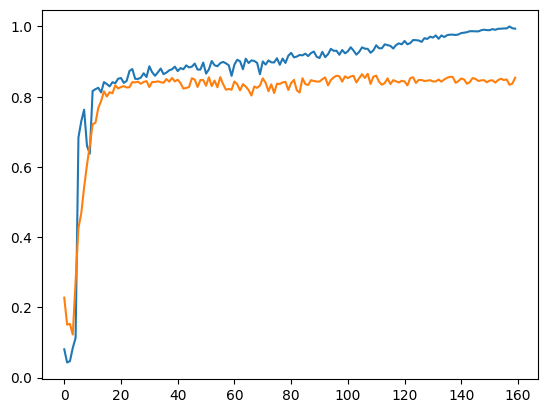

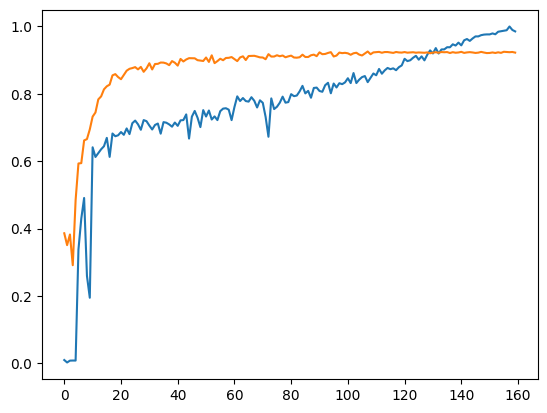

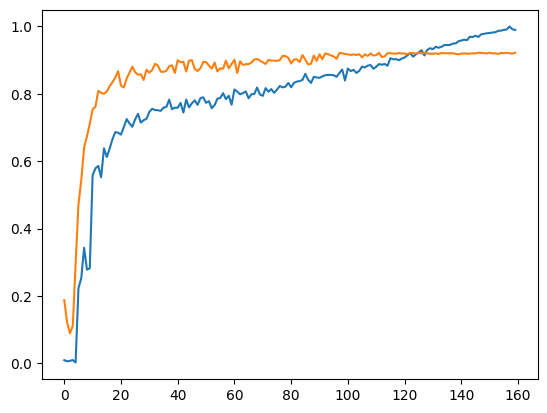

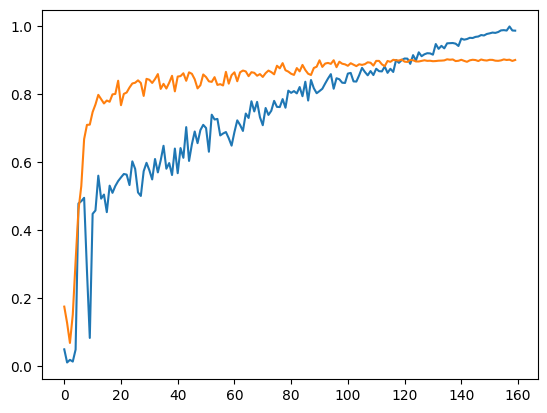

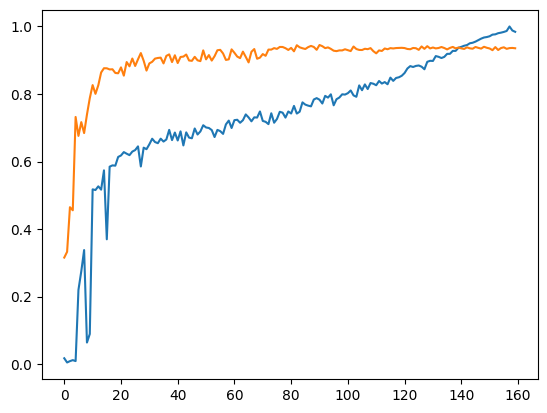

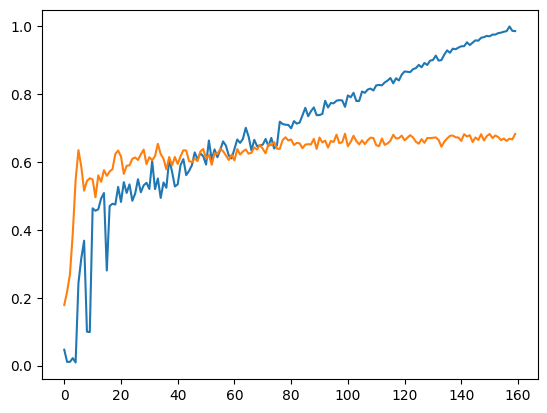

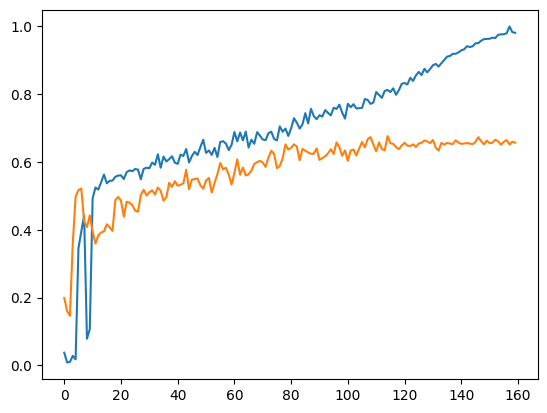

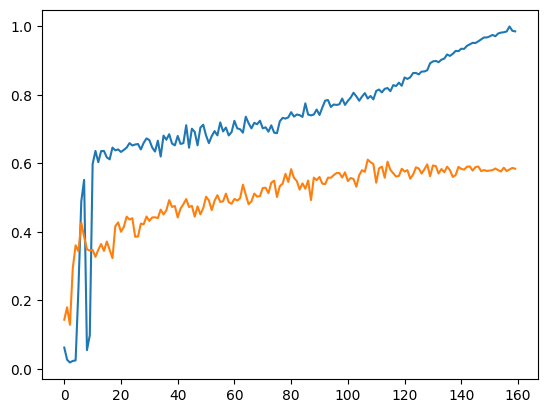

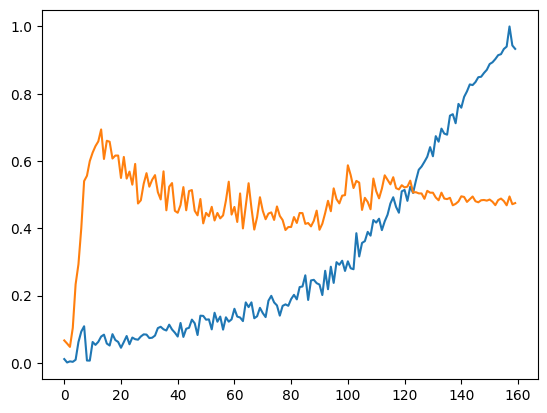

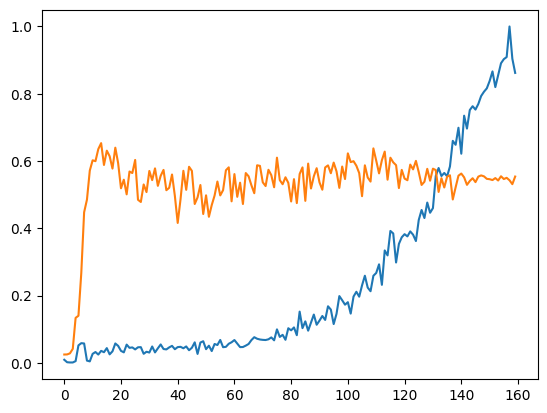

IndexError: index 20 is out of bounds for axis 1 with size 20

In [35]:
# Compare CKA values of experiment with failed weights and new weights
def plot_results_plotly(all_epochs_matrix, all_epochs_matrix2, layer_types='s'):
    # Convert PyTorch tensor to NumPy if needed
    if isinstance(all_epochs_matrix, torch.Tensor):
        all_epochs_matrix = all_epochs_matrix.cpu().numpy()
    if isinstance(all_epochs_matrix2, torch.Tensor):
        all_epochs_matrix2 = all_epochs_matrix2.cpu().numpy()

    num_rows, num_cols = all_epochs_matrix.shape
    time_steps = np.arange(num_rows)

    if layer_types == 's':
        for i in range(number_of_cnn_layers):
            plt.plot(time_steps, all_epochs_matrix[:, i])
            plt.plot(time_steps, all_epochs_matrix2[:, i])
            plt.show()
cka_over_time_file = f"{experiment_one}/seed_{experiment_one_seed}/resnet50_cka_values_across_epochs.pkl"
cka_over_time_file2 = f"{experiment_two}/seed_{experiment_two_seed}/resnet50_cka_values_across_epochs.pkl"
with open(cka_over_time_file2, "rb") as f:
  cka_over_time2 = pickle.load(f)
  list_of_layers = list(cka_over_time2.keys())
  max_epochs = max(len(cka_over_time2[key]) for key in list(cka_over_time2.keys()))
  max_layers = len(list_of_layers)
  cka_matrix = torch.zeros((max_layers, max_epochs))
  for layer_index, layer in enumerate(list_of_layers):
      max_epochs_trained_for_layer = len(cka_over_time2[layer])
      for epoch in range(max_epochs_trained_for_layer):
          cka_matrix[layer_index][epoch] = cka_over_time2[layer][epoch]
  all_epochs_matrix2 = cka_matrix.T
  # print(all_epochs_matrix2)
  
with open(cka_over_time_file, 'rb') as f:
  cka_over_time = pickle.load(f)
  list_of_layers = list(cka_over_time.keys())
  # print(f"List of Layers: {list_of_layers}")
  max_epochs = max(len(cka_over_time[key]) for key in list(cka_over_time.keys()))
  max_layers = len(list_of_layers)
  cka_matrix = torch.zeros((max_layers, max_epochs))
  for layer_index, layer in enumerate(list_of_layers):
      max_epochs_trained_for_layer = len(cka_over_time[layer])
      for epoch in range(max_epochs_trained_for_layer):
          cka_matrix[layer_index][epoch] = cka_over_time[layer][epoch]
  all_epochs_matrix = cka_matrix.T
  # print(all_epochs_matrix)
plot_results_plotly(all_epochs_matrix, all_epochs_matrix2, layer_types='s')
# plot_results_plotly(all_epochs_matrix, layer_types='m')
# plot_results_plotly(all_epochs_matrix, layer_types='e')

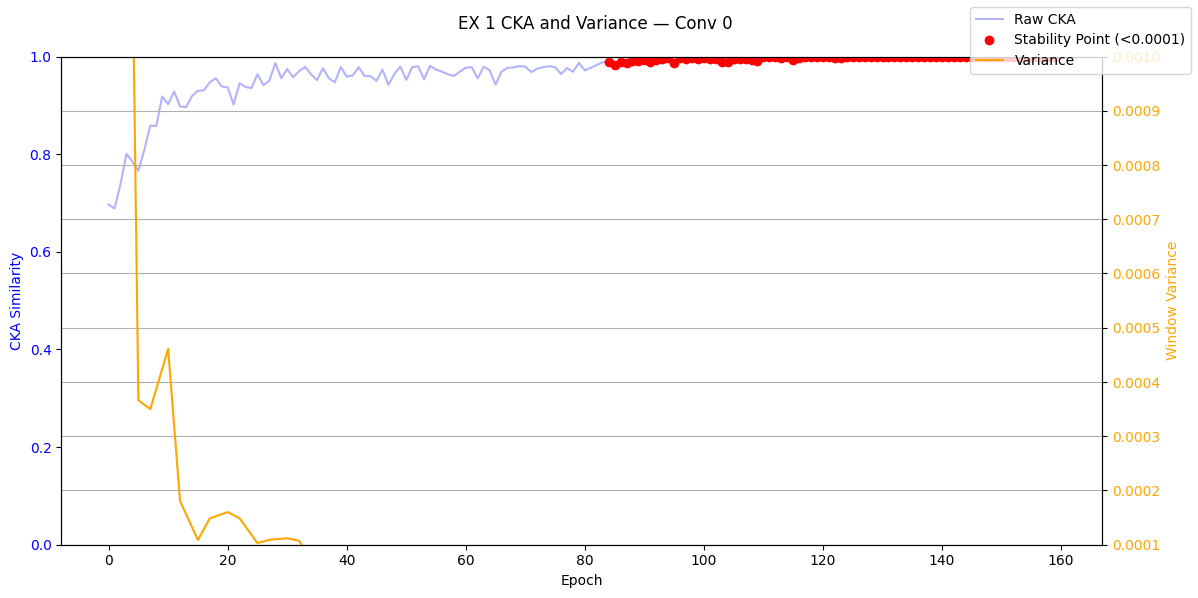

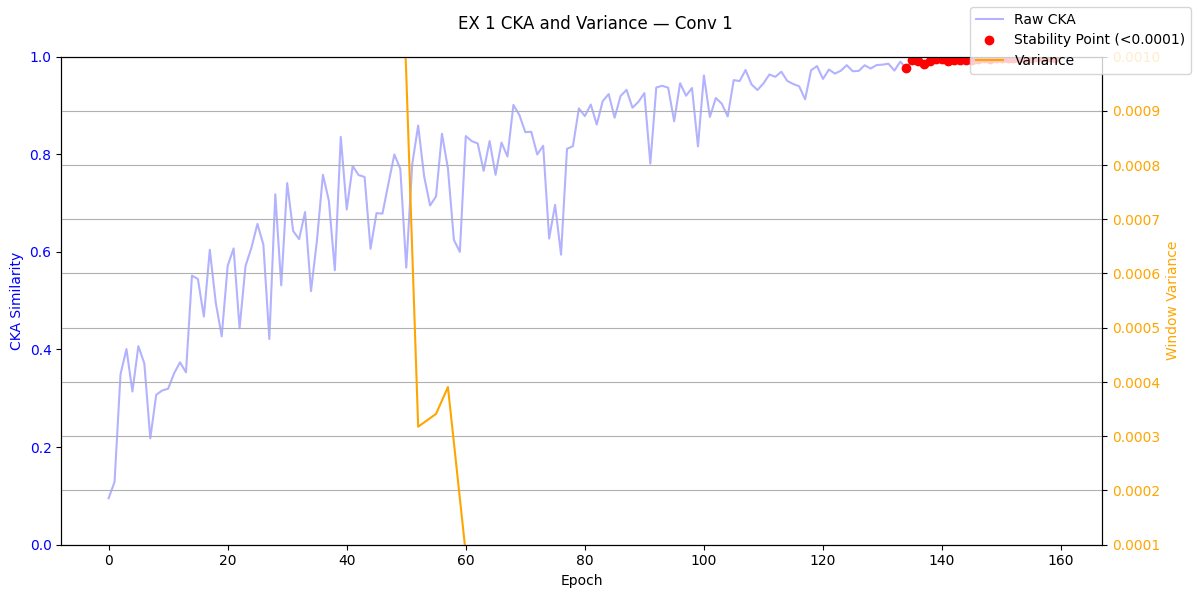

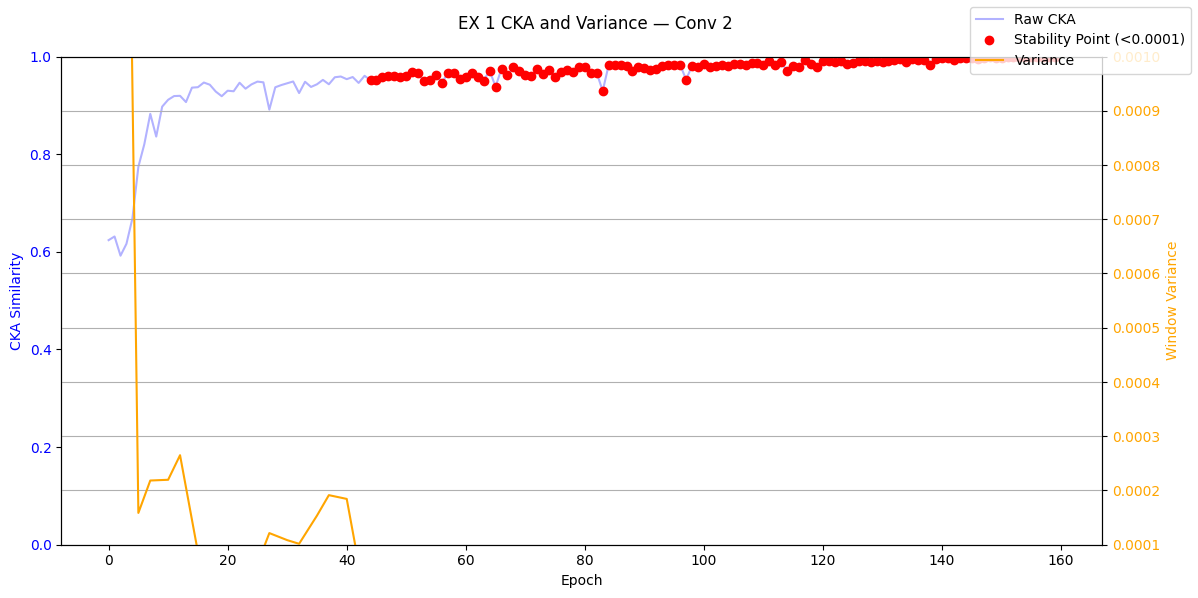

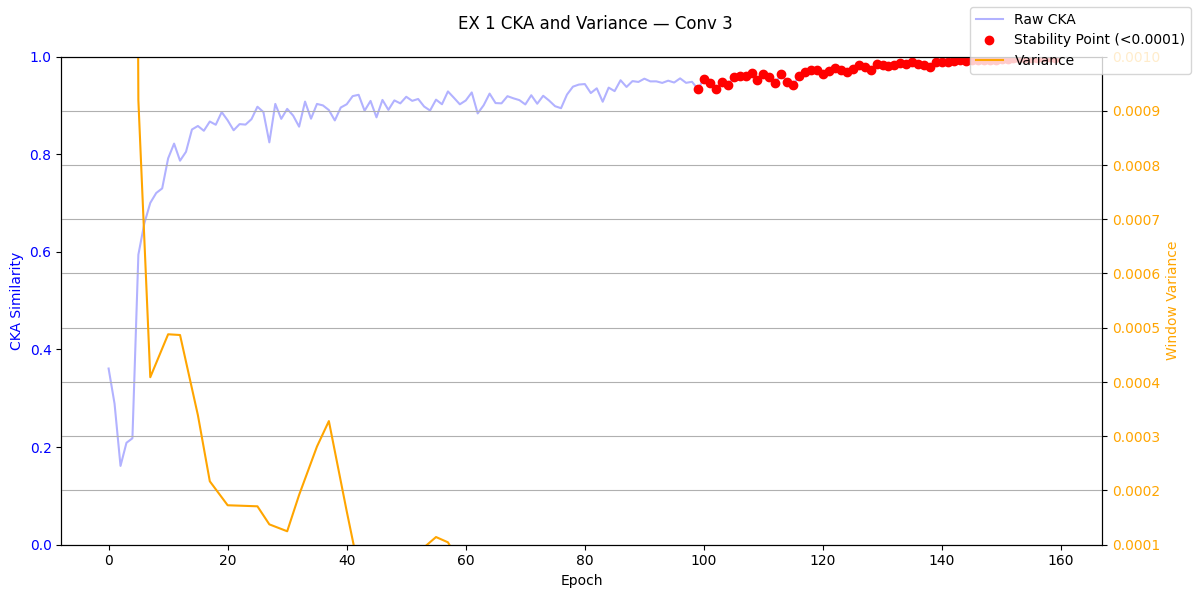

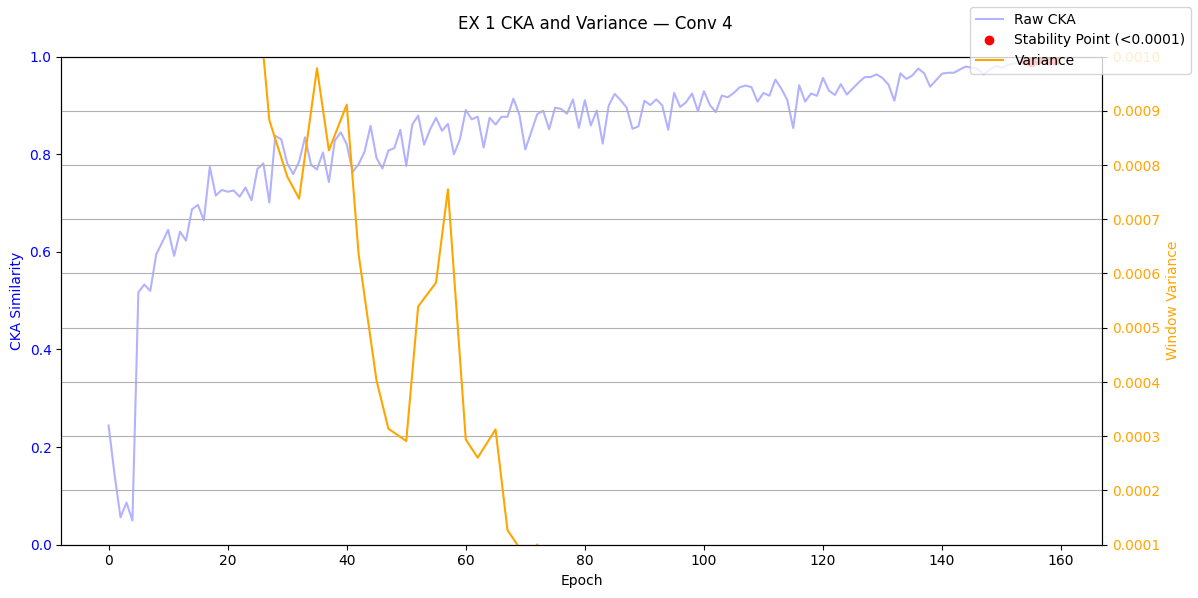

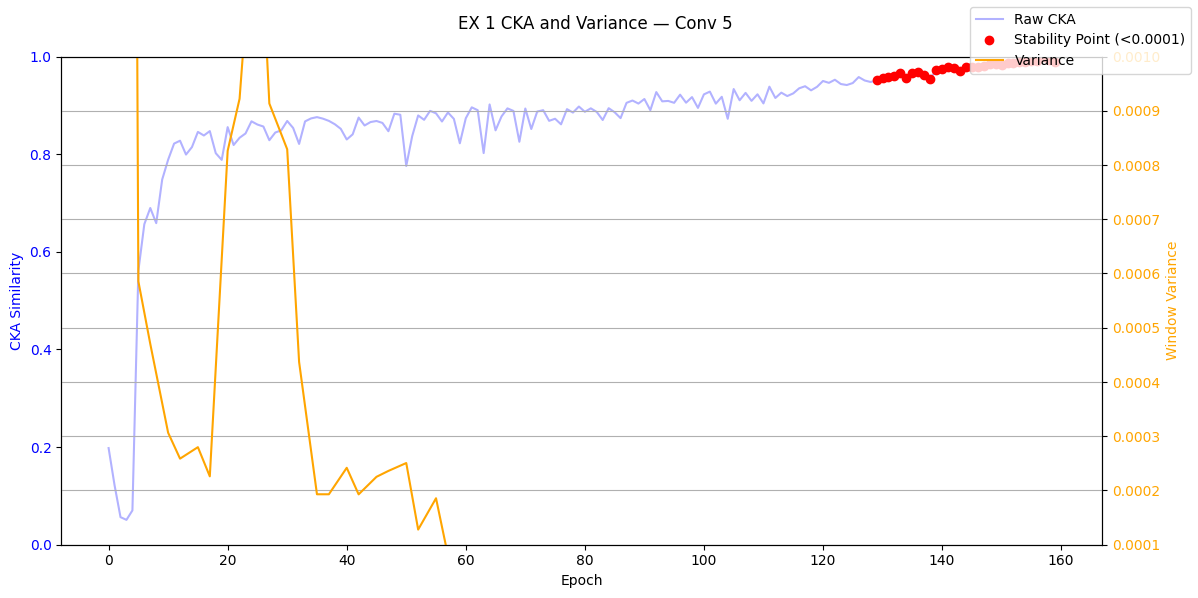

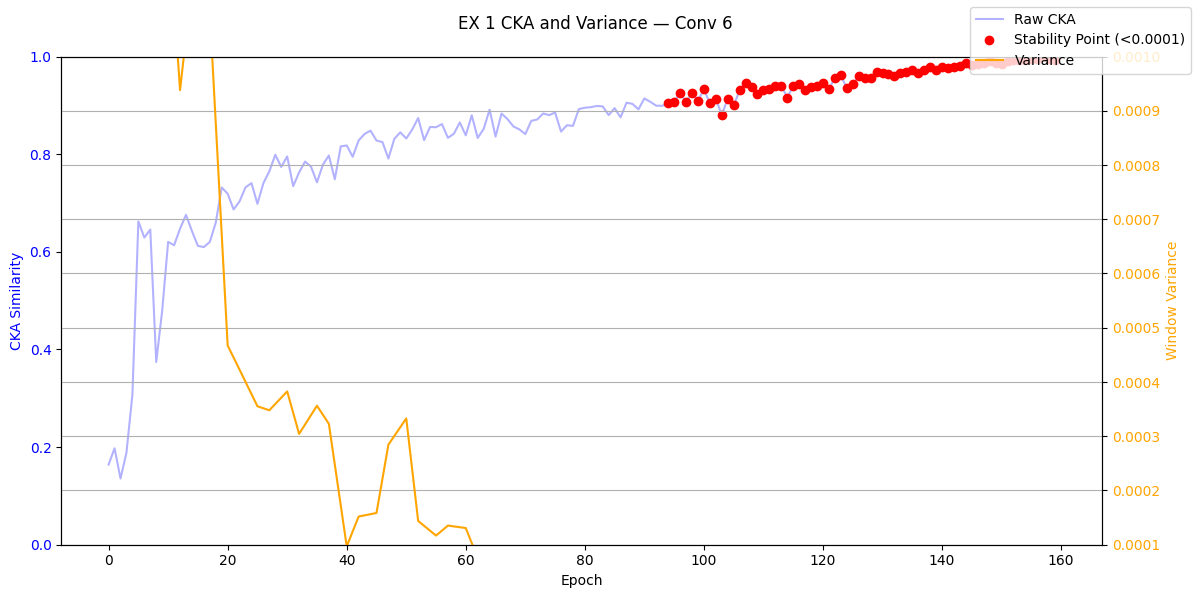

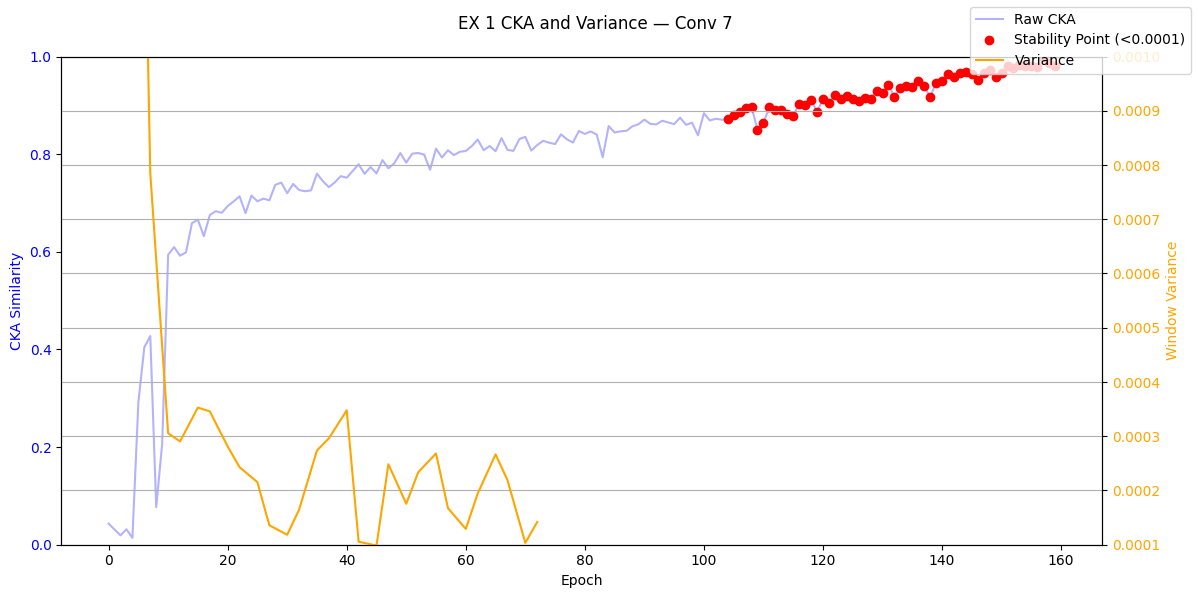

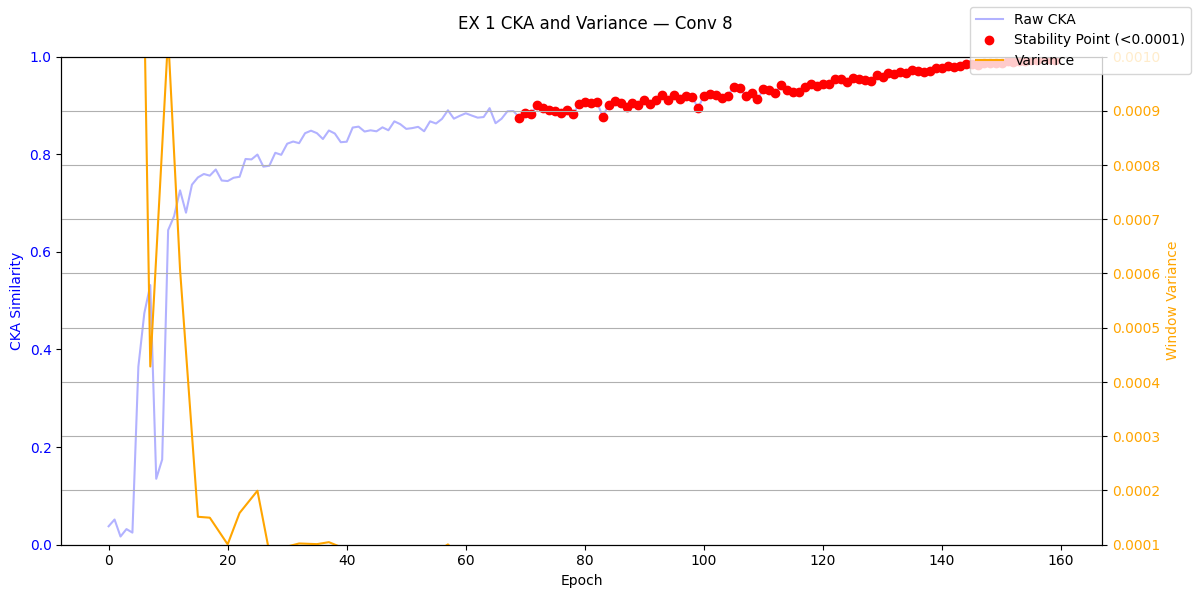

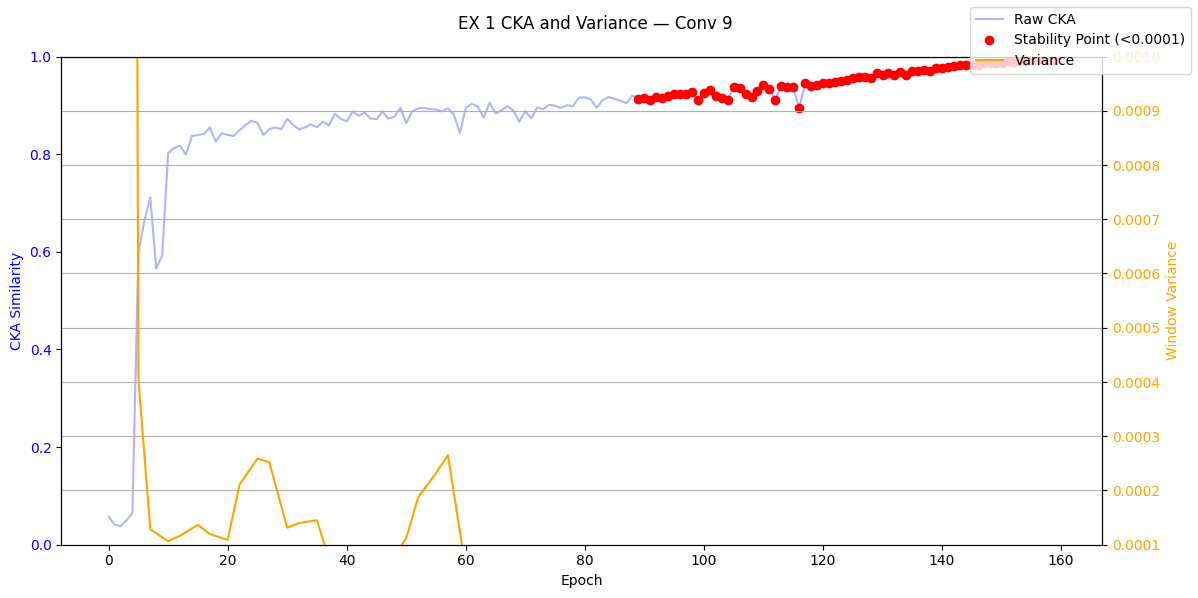

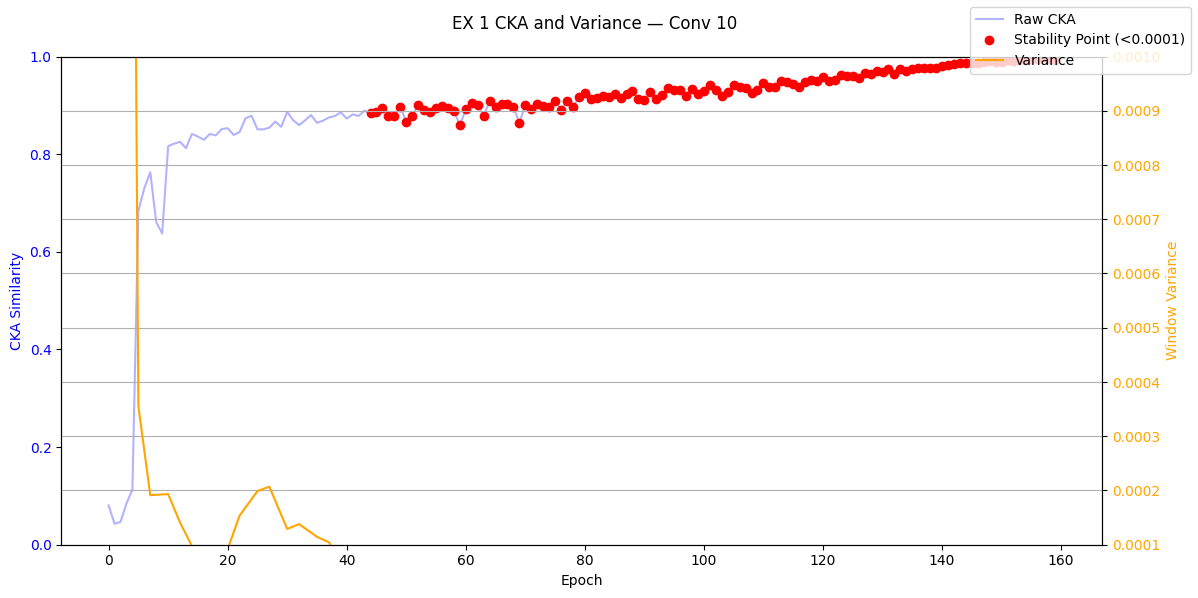

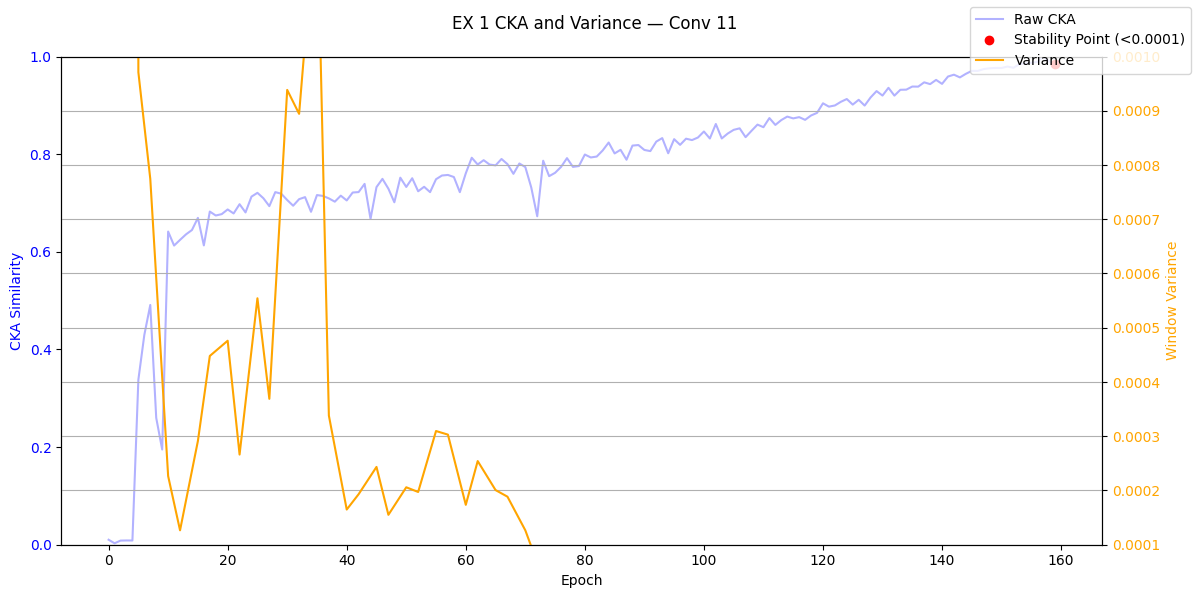

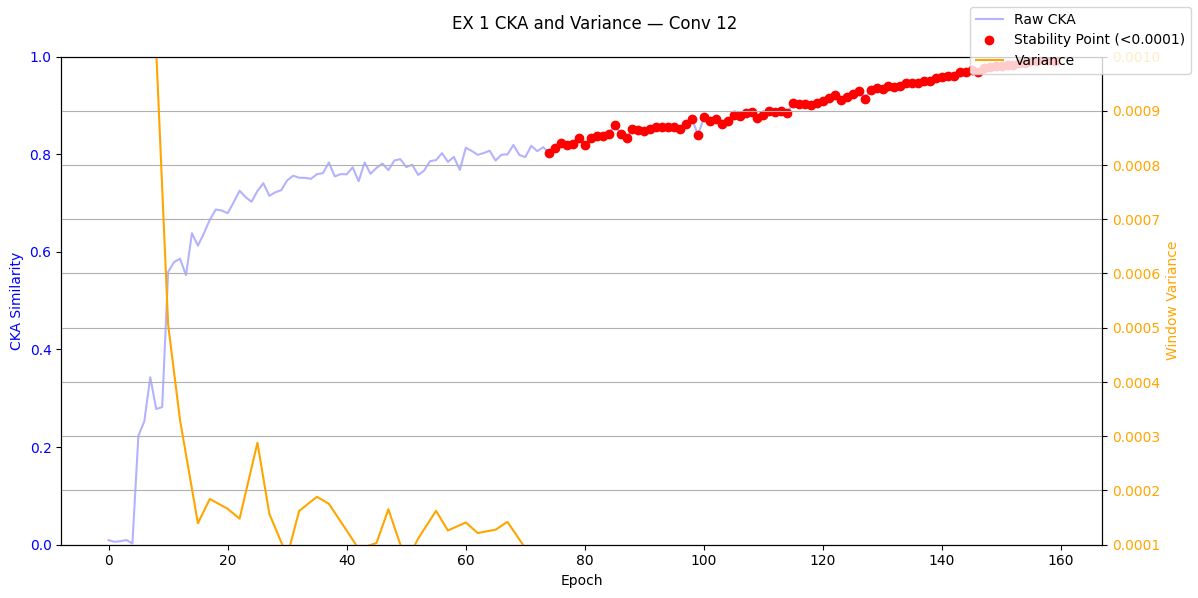

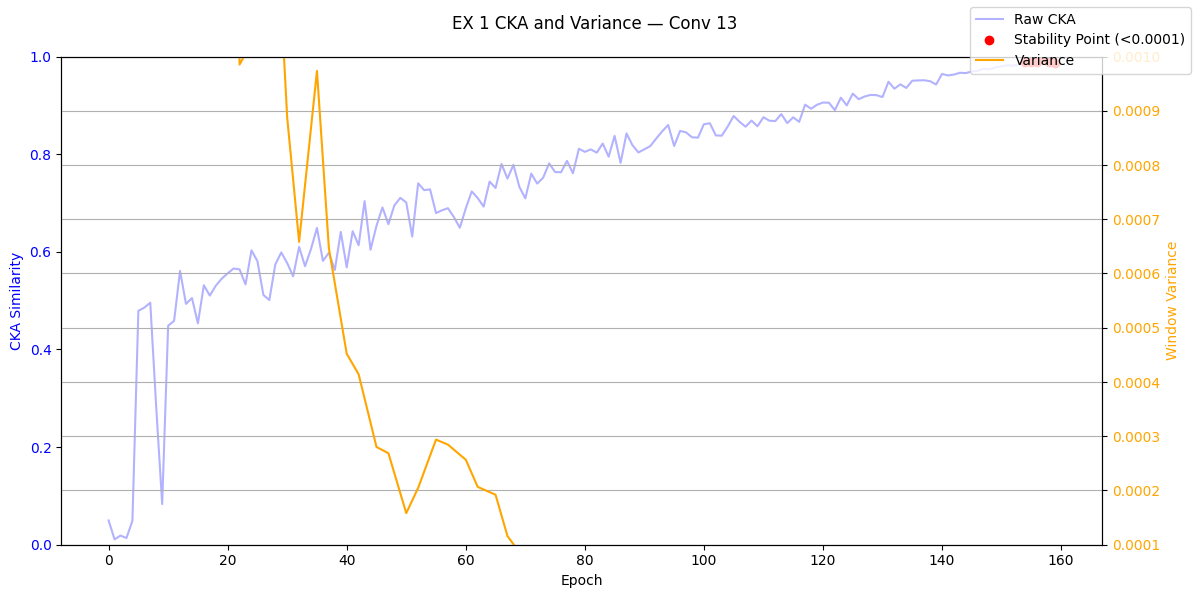

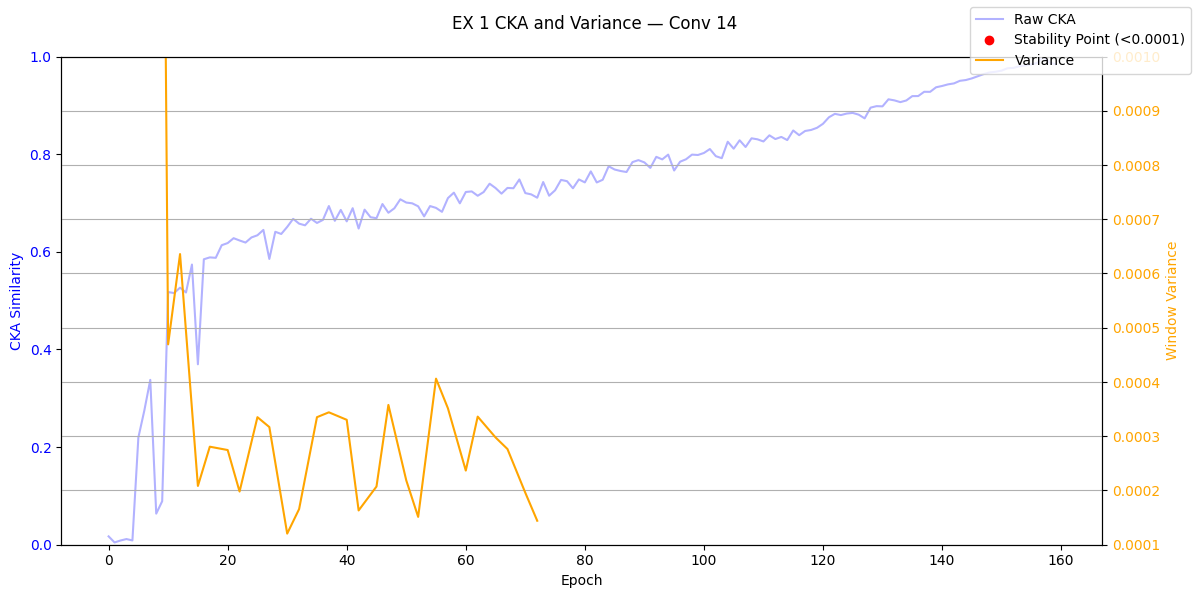

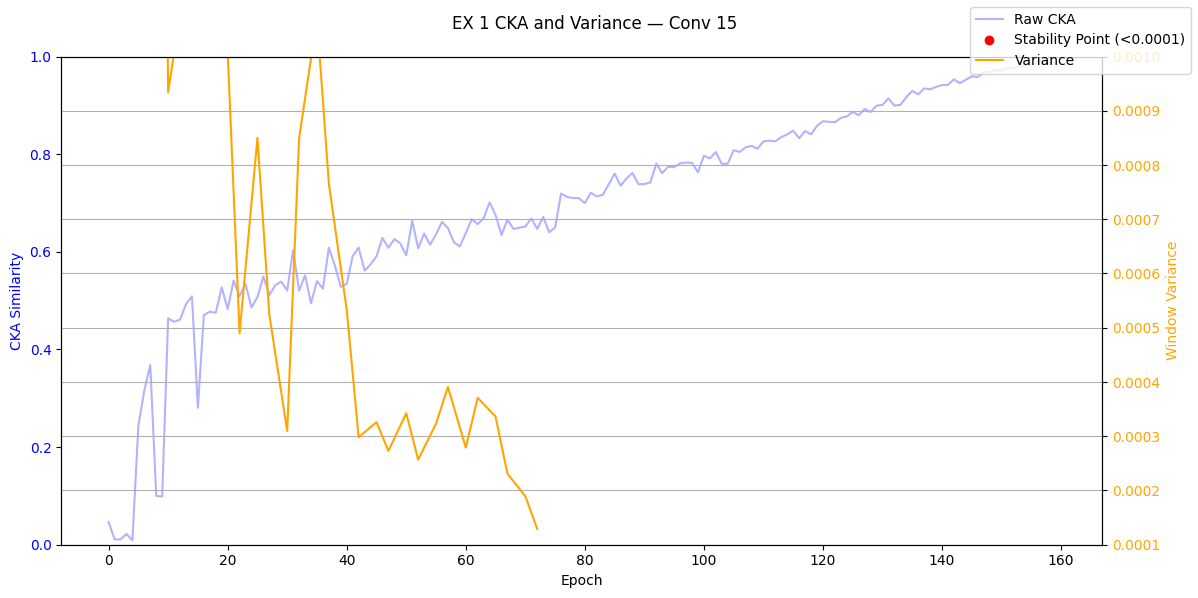

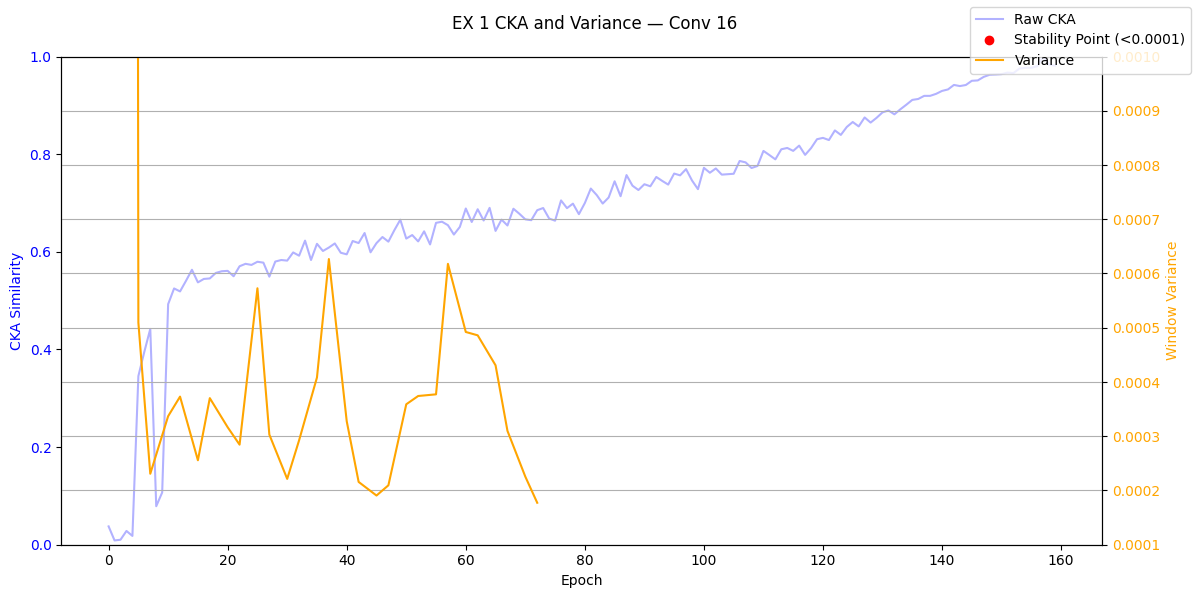

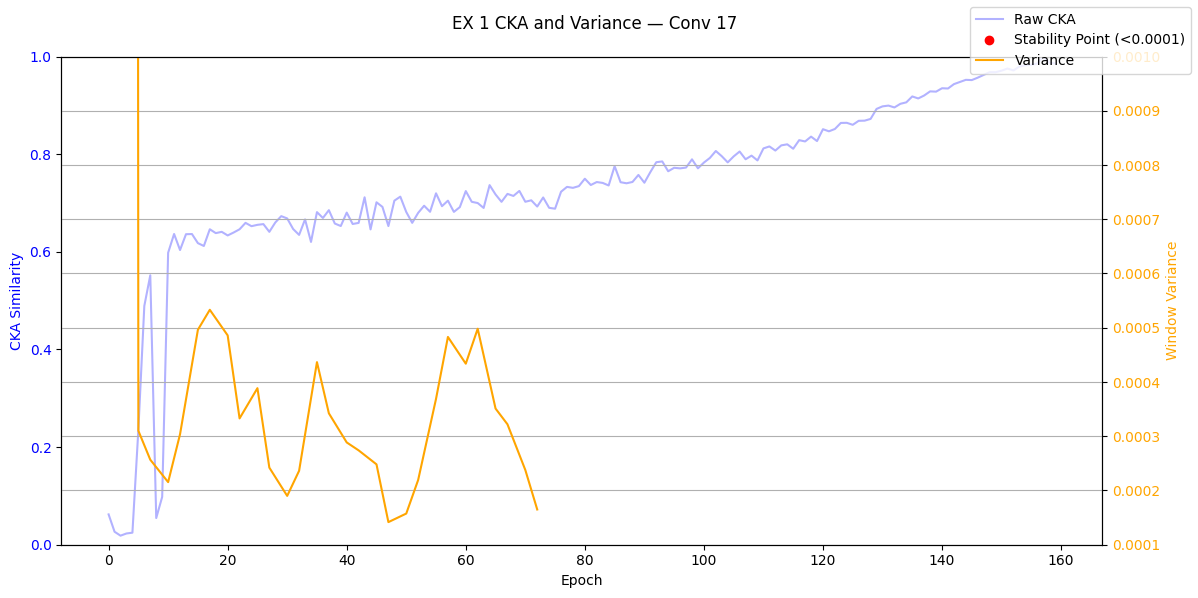

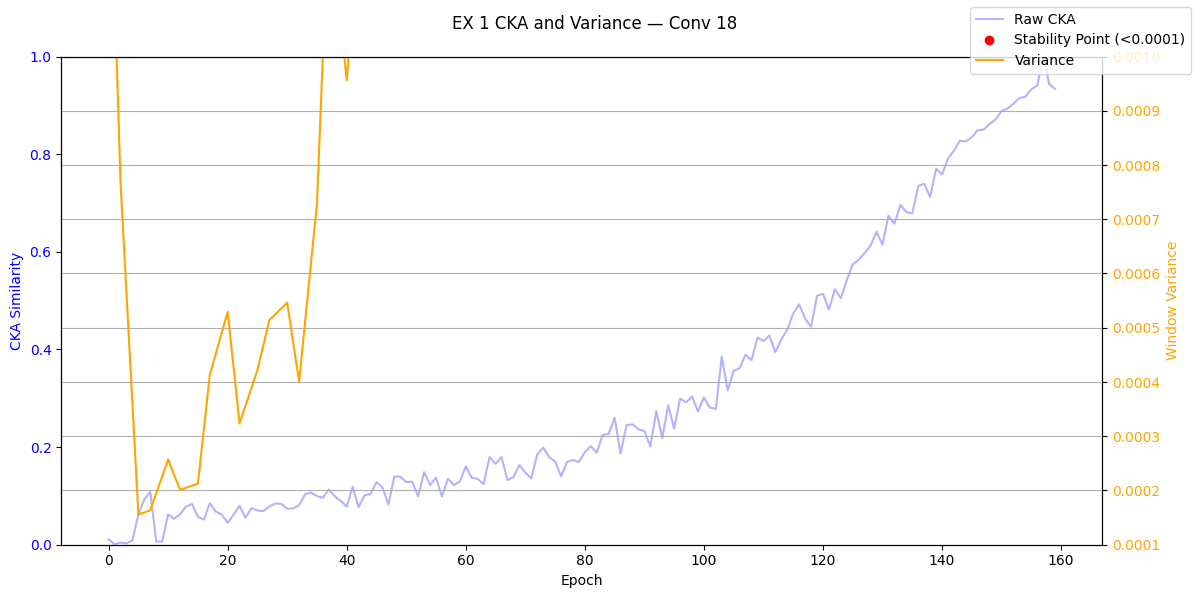

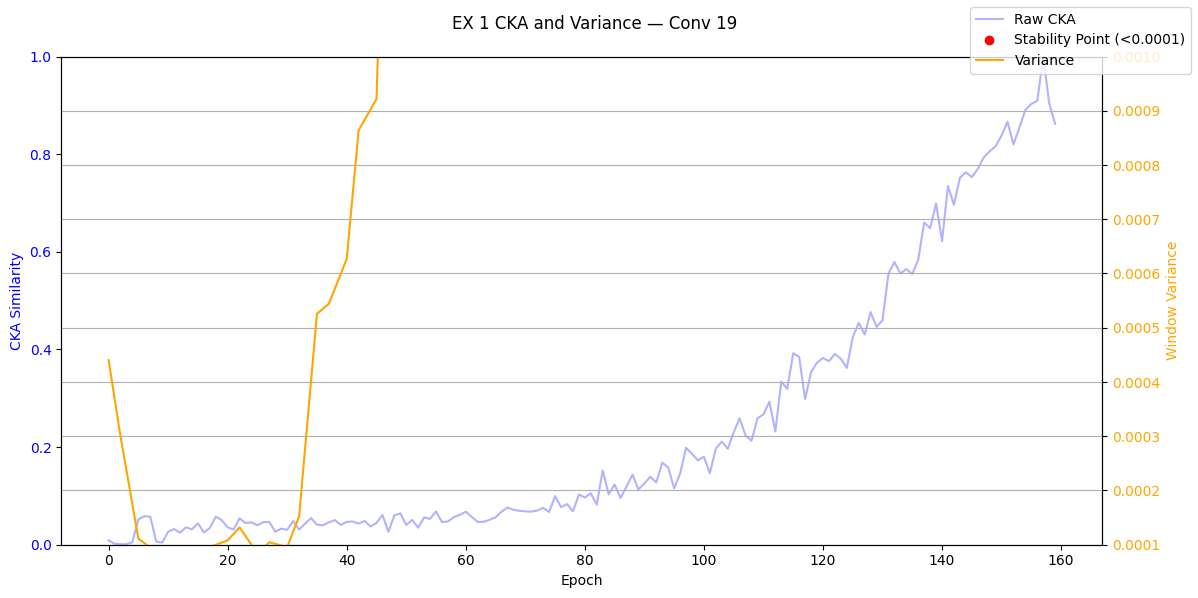

IndexError: index 20 is out of bounds for dimension 1 with size 20

In [36]:
import numpy as np
import matplotlib.pyplot as plt
def get_all_stability_points_for_all_layers(
    all_epochs_matrix, conv_indices, moving_window=15, stride=5, stability_threshold=0.0001, layers=None
):
    if layers is not None:
      cka_freeze_configuration = {layer: [] for layer in layers}
    num_epochs = all_epochs_matrix.shape[0]

    for conv_idx in conv_indices:
        cka_vals = all_epochs_matrix[:, conv_idx]
        if hasattr(cka_vals, 'cpu'):
            cka_vals = cka_vals.cpu().numpy()

        cka_window_values = []
        variance_values = []   # Store variance for plotting
        variance_epochs = []   # Track the center of the window for plotting

        prev_decision_was_frozen = False
        prev_CKA_at_decision_for_frozen = None

        for epoch, cka_val in enumerate(cka_vals):
            cka_window_values.append(cka_val)

            if len(cka_window_values) > moving_window:
                cka_window_values = cka_window_values[stride:]

            if len(cka_window_values) == moving_window:
                window_variance = np.var(cka_window_values, ddof=1)

                center_epoch = (epoch - moving_window + 1) // 2
                start_of_epoch = epoch - moving_window + 1
                # print(f"The Current Epoch: {epoch}, Start of Epoch: {epoch} - {moving_window} = {start_of_epoch}")
                variance_values.append(window_variance)
                variance_epochs.append(center_epoch)
                # After the initial freeze decision, make it so that all labels subsequently are of a frozen layer
                # Doesn't make sense to go back and forth with freezing, measure performance difference after. Weights should change slightly anyway
                if window_variance < stability_threshold and cka_val > 0.3 or cka_freeze_configuration[layers[conv_idx]][-1] == 1:
                    # print(f"Layer {conv_idx} — CKA value when freezing: ", cka_val)
                    # print("Variance of window: ", window_variance)
                    cka_freeze_configuration[layers[conv_idx]].append(1) # 1 for frozen layer
                    # cka_freeze_configuration[layers[conv_idx]][-moving_window:] = [1] * moving_window # replace last moving_window elements with 1 for frz
                    prev_decision_was_frozen = True
                    prev_CKA_at_decision_for_frozen = cka_val
                else:
                  cka_freeze_configuration[layers[conv_idx]].append(0) # 0 for non-frozen layer
                  prev_decision_was_frozen = False
                  prev_CKA_at_decision_for_frozen = None
            else:
              if prev_decision_was_frozen:
                # Get percent change, has to be a less than 3% change from the CKA value that was previously frozen at
                prev_cka_value_pct_change = abs(prev_CKA_at_decision_for_frozen - cka_val) / prev_CKA_at_decision_for_frozen
                if prev_cka_value_pct_change < 0.1:
                  cka_freeze_configuration[layers[conv_idx]].append(1) # following previous decision of layer freezing
                else:
                  print("GREATER THAN 3% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER")
                  cka_freeze_configuration[layers[conv_idx]].append(0)
              else:
                cka_freeze_configuration[layers[conv_idx]].append(0) # following previous decision of layer freezing, or there haven't been enough epochs for test

        # Plotting
        fig, ax1 = plt.subplots(figsize=(12, 6))

        ax1.plot(cka_vals, label='Raw CKA', color='blue', alpha=0.3)
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('CKA Similarity', color='blue')
        ax1.tick_params(axis='y', labelcolor='blue')
        ax1.set_ylim(0, 1.0)

        # Plot variance on secondary axis
        ax2 = ax1.twinx()
        ax2.plot(variance_epochs, variance_values, label='Variance', color='orange')
        ax2.set_ylabel('Window Variance', color='orange')
        ax2.set_ylim(0.0001, 0.001)
        ax2.tick_params(axis='y', labelcolor='orange')

        # Plot the first stability marker if found
        frz_moment = [epoch_index for epoch_index, frz_decision in enumerate(cka_freeze_configuration[layers[conv_idx]]) if frz_decision == 1]
        cka_val_at_frz_moment = [cka_vals[epoch_index] for epoch_index in frz_moment]
        if frz_moment is not None:
            ax1.plot(frz_moment, cka_val_at_frz_moment, 'ro', label=f'Stability Point (<{stability_threshold})')

        fig.suptitle(f'EX 1 CKA and Variance — Conv {conv_idx}')
        fig.tight_layout()
        fig.legend(loc='upper right')
        plt.grid(True)
        plt.show()

    if layers is not None:
      return cka_freeze_configuration
with open(f"{experiment_one}/seed_{experiment_one_seed}/cka_freeze_layer_decisions.pkl", "rb") as f:
    cka_freeze_layer_decisions = pickle.load(f)
layers = list(cka_freeze_layer_decisions.keys())
cka_freeze_layer_configuration = get_all_stability_points_for_all_layers(all_epochs_matrix, conv_indices=[i for i in range(53)], layers=layers)

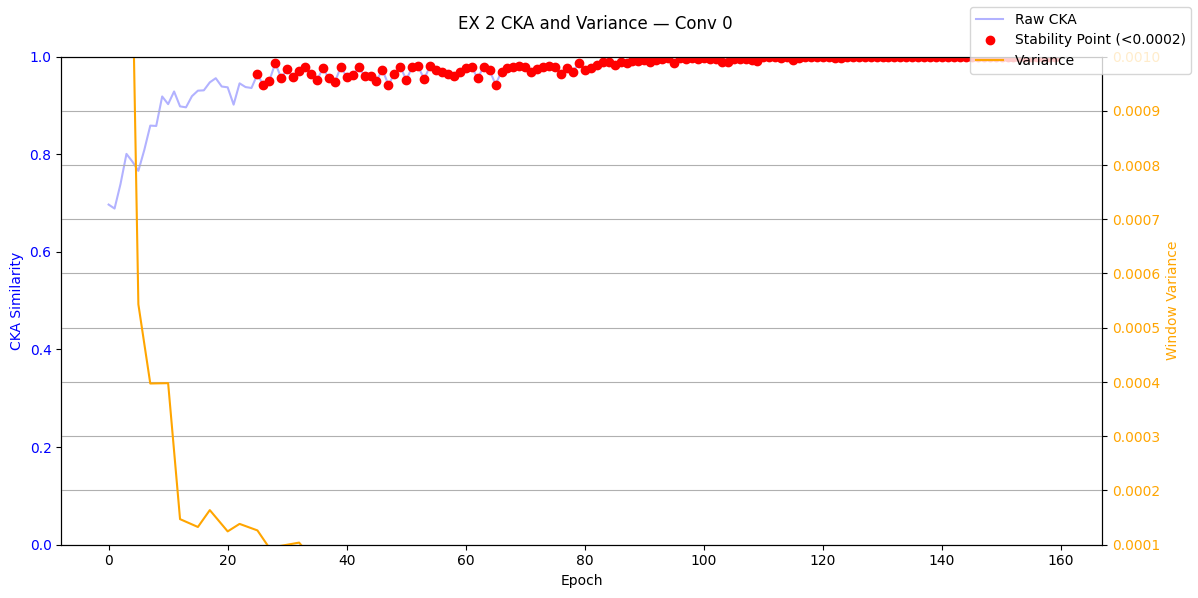

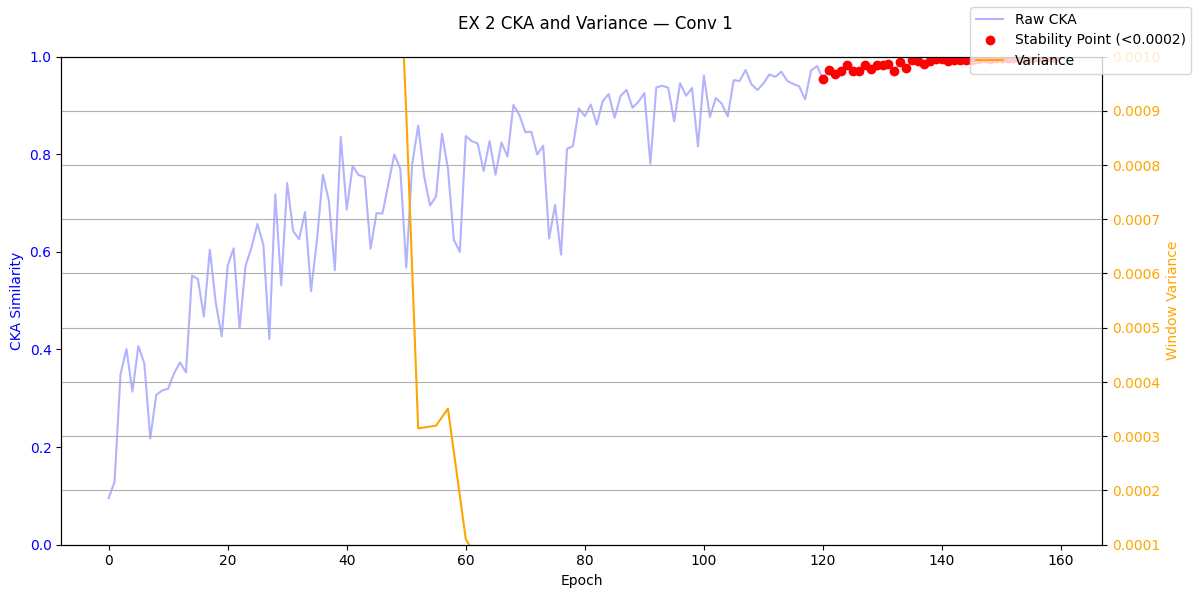

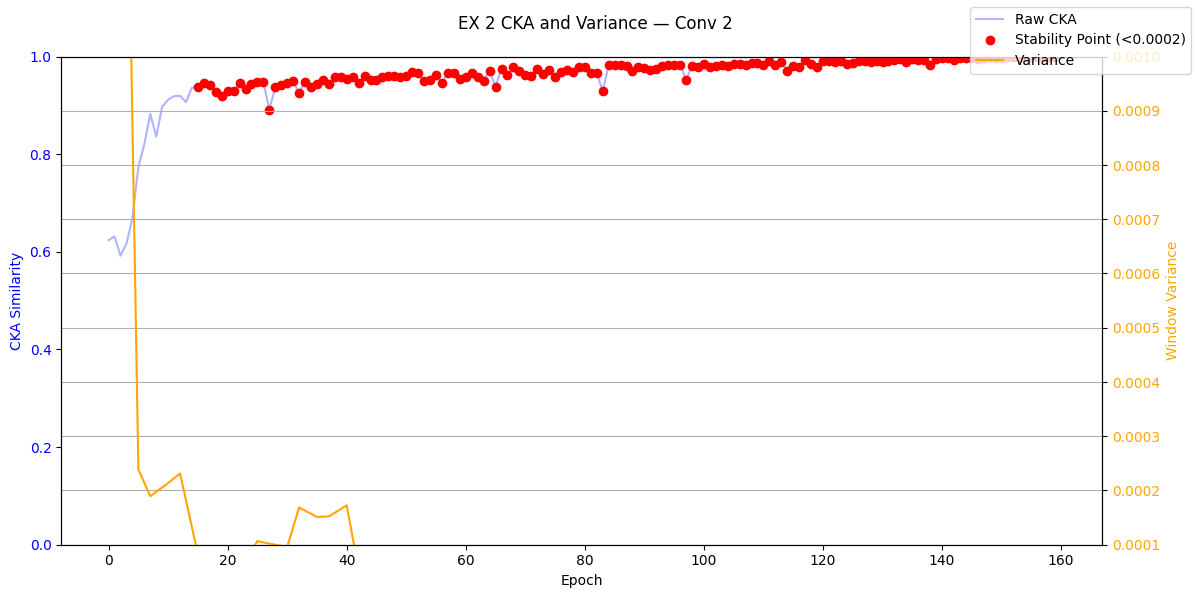

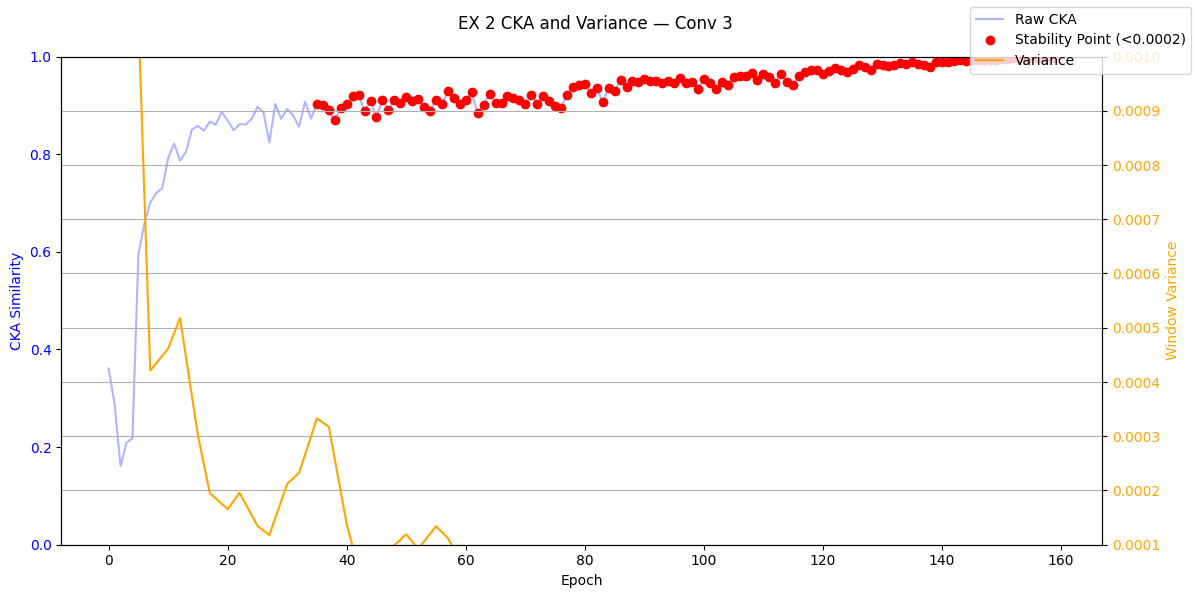

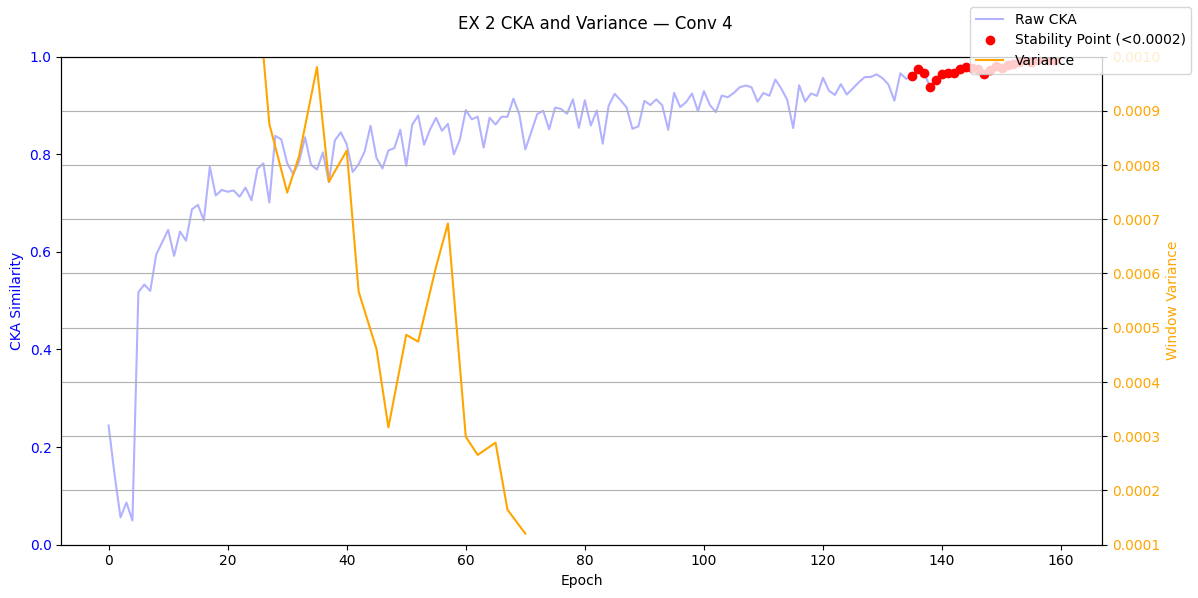

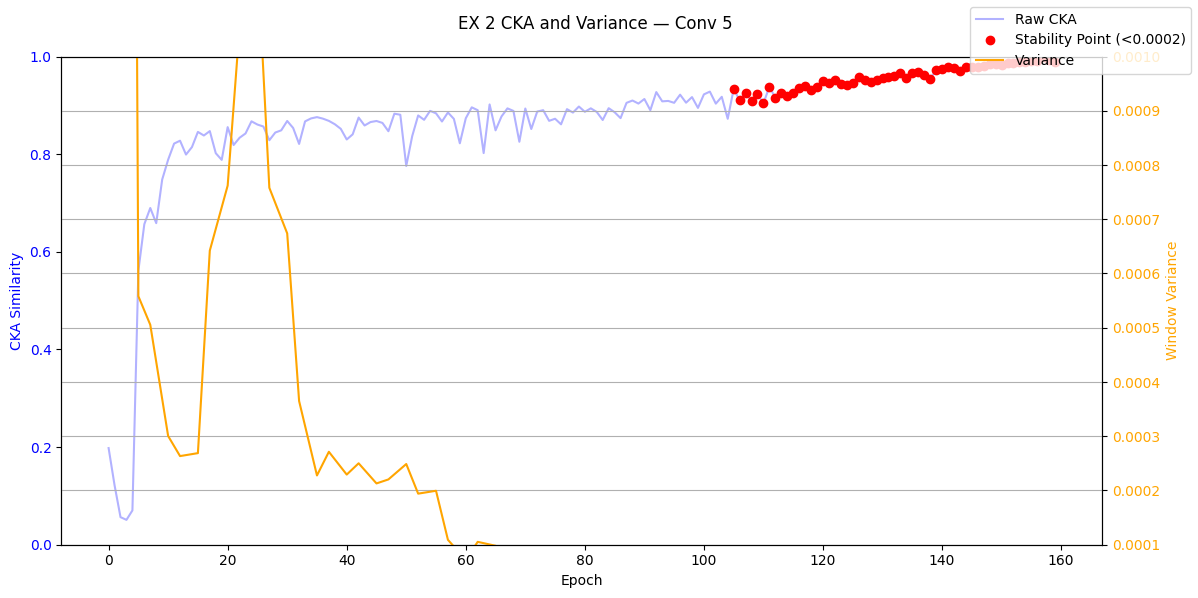

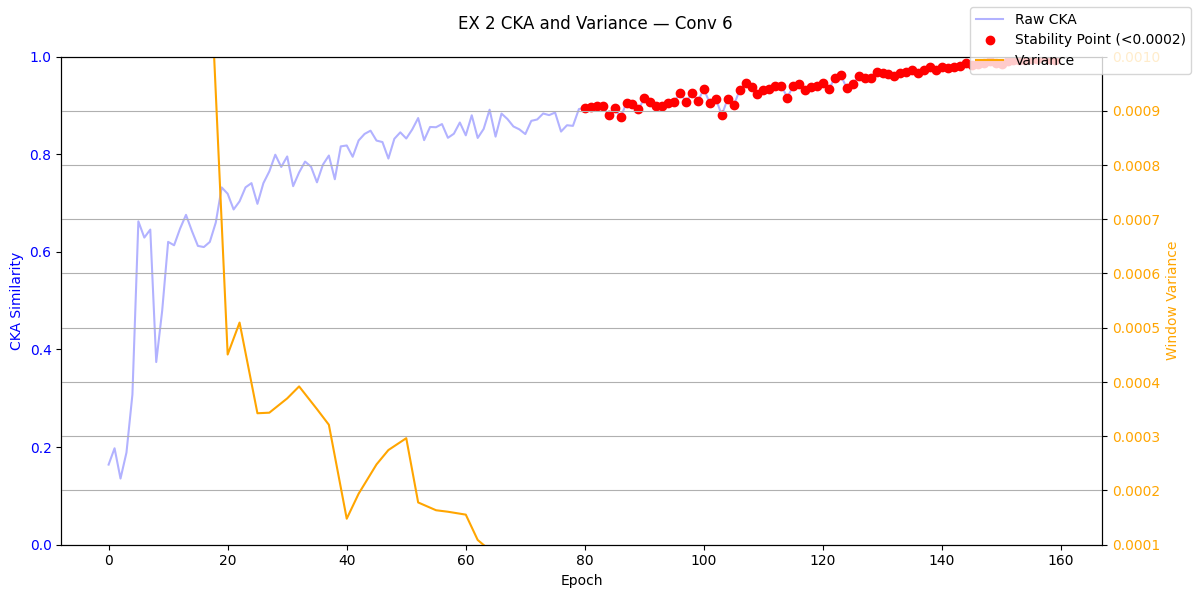

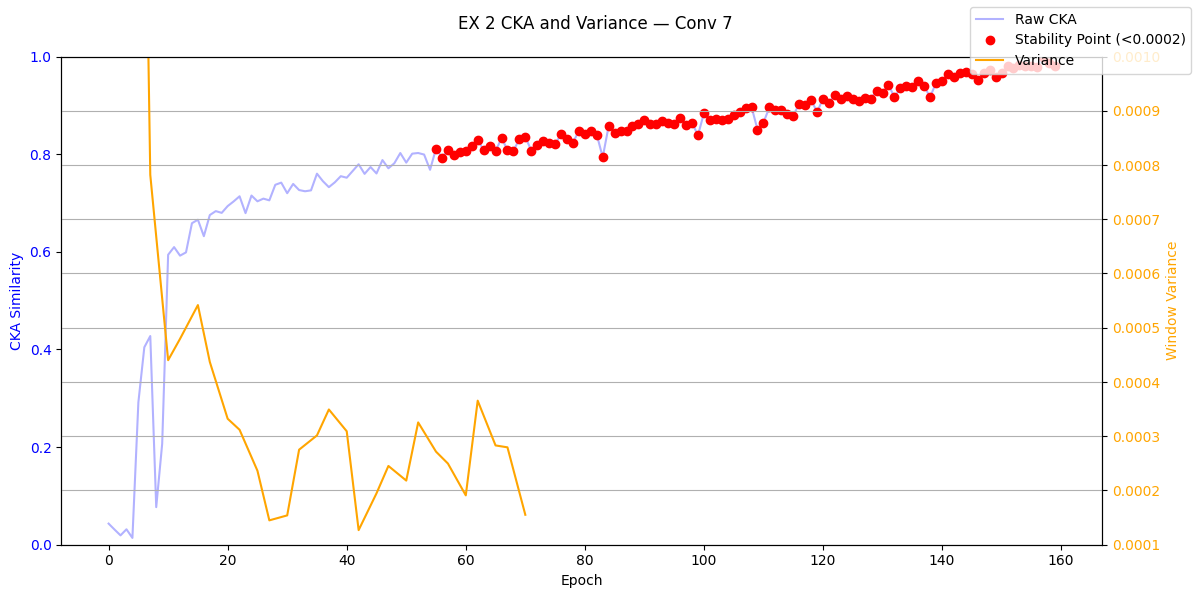

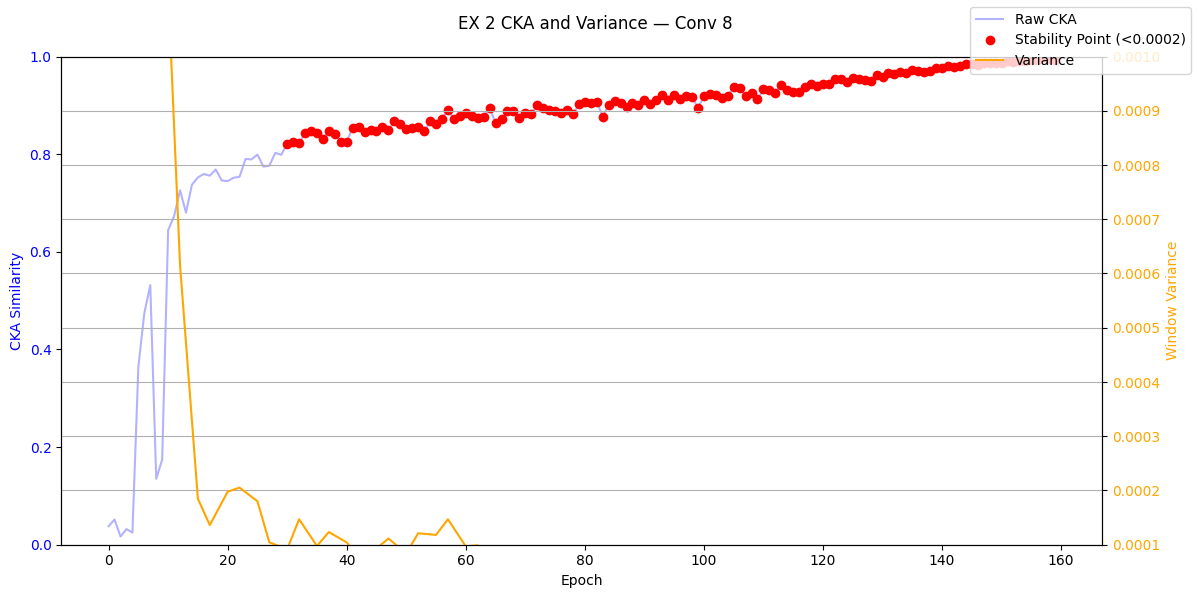

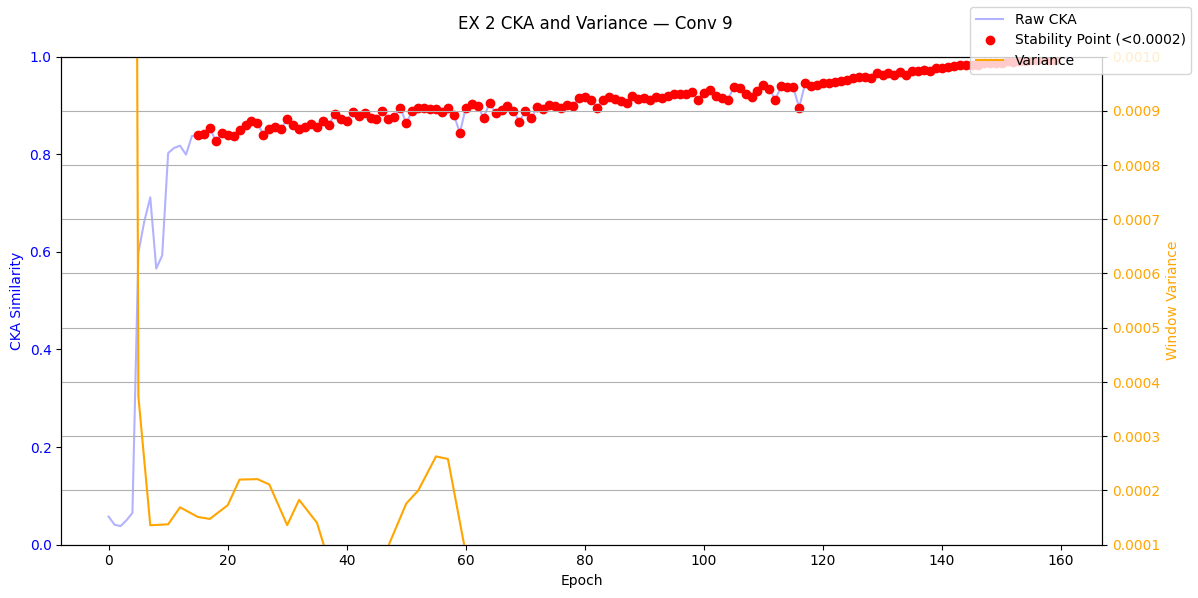

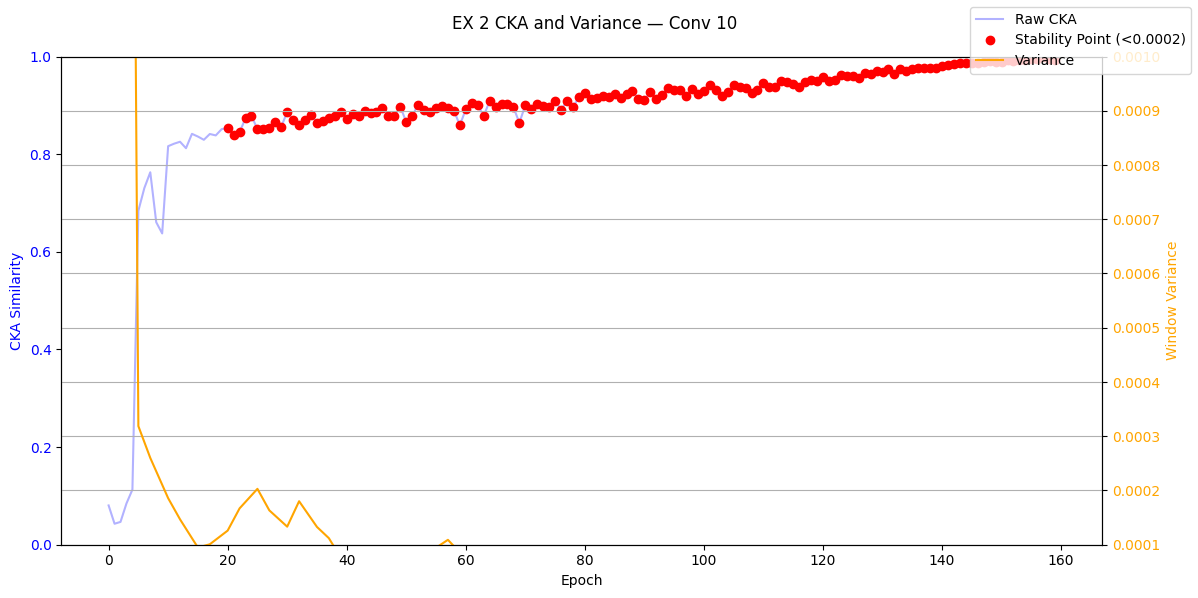

GREATER THAN 3% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 3% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER


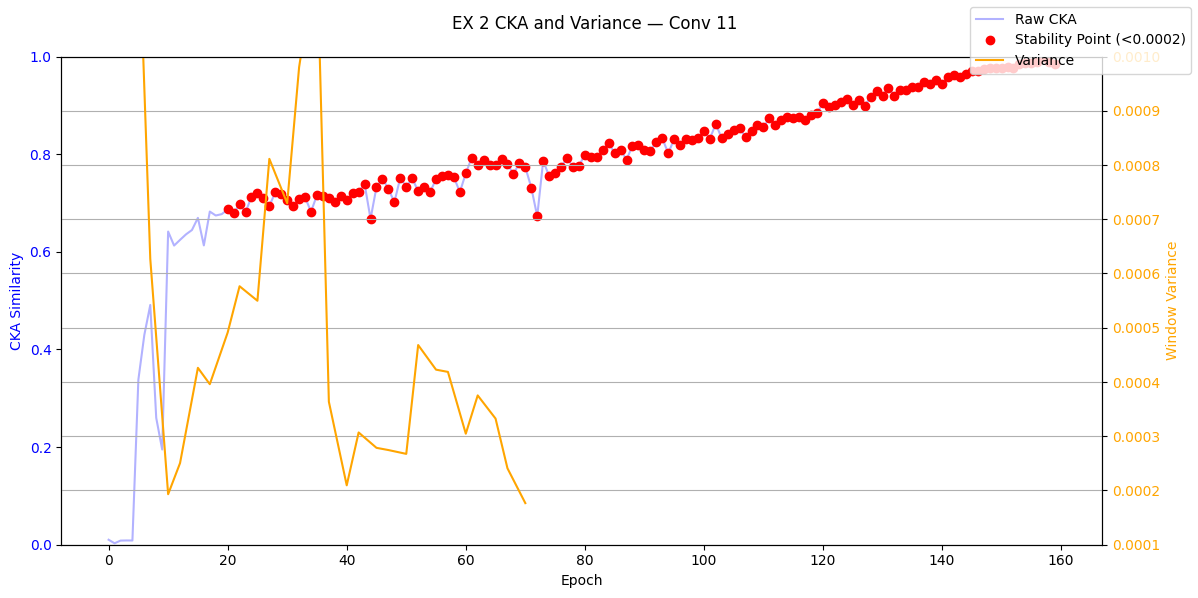

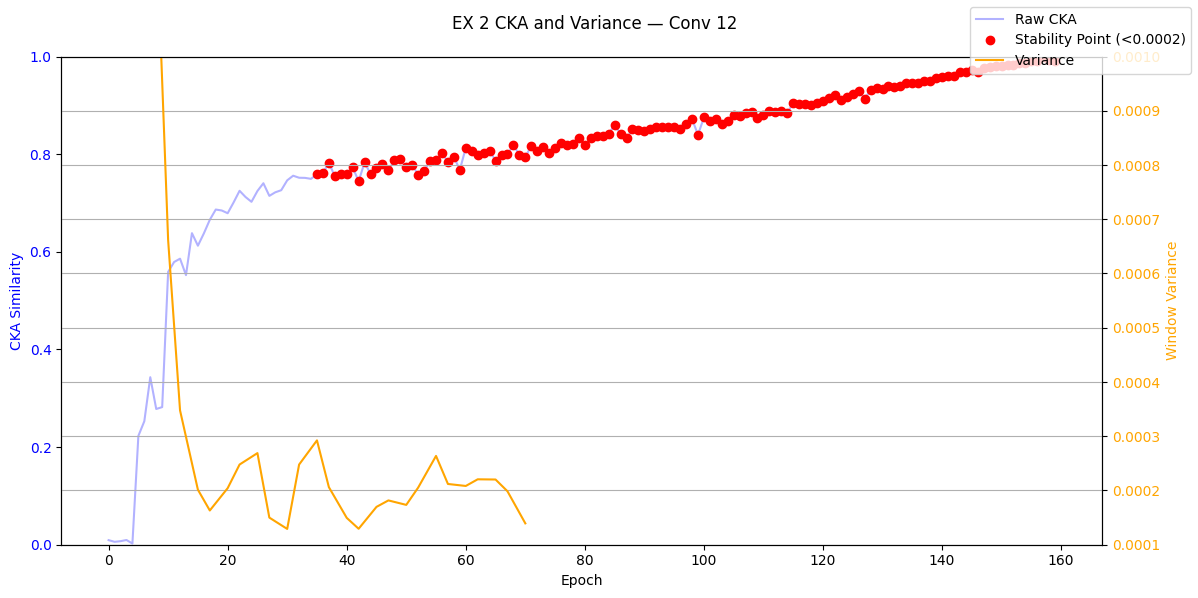

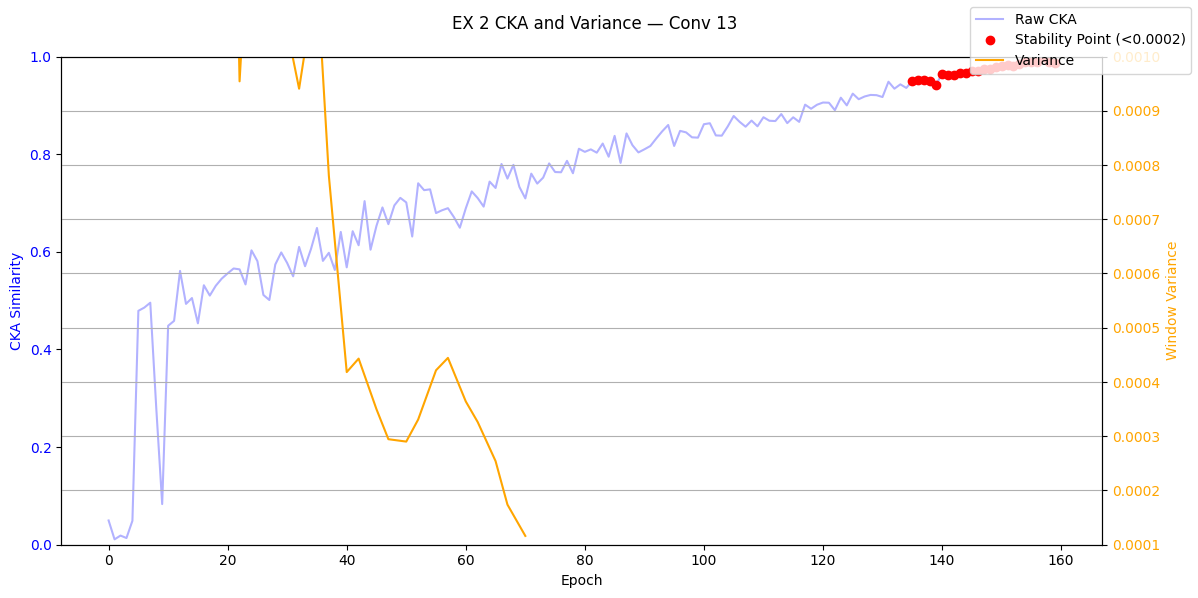

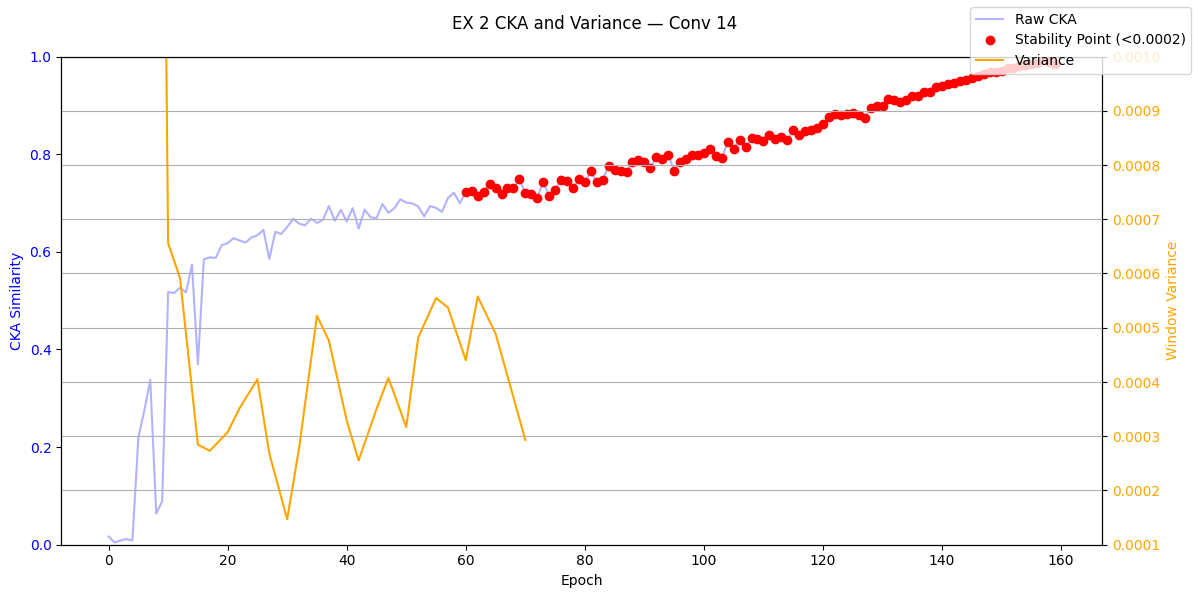

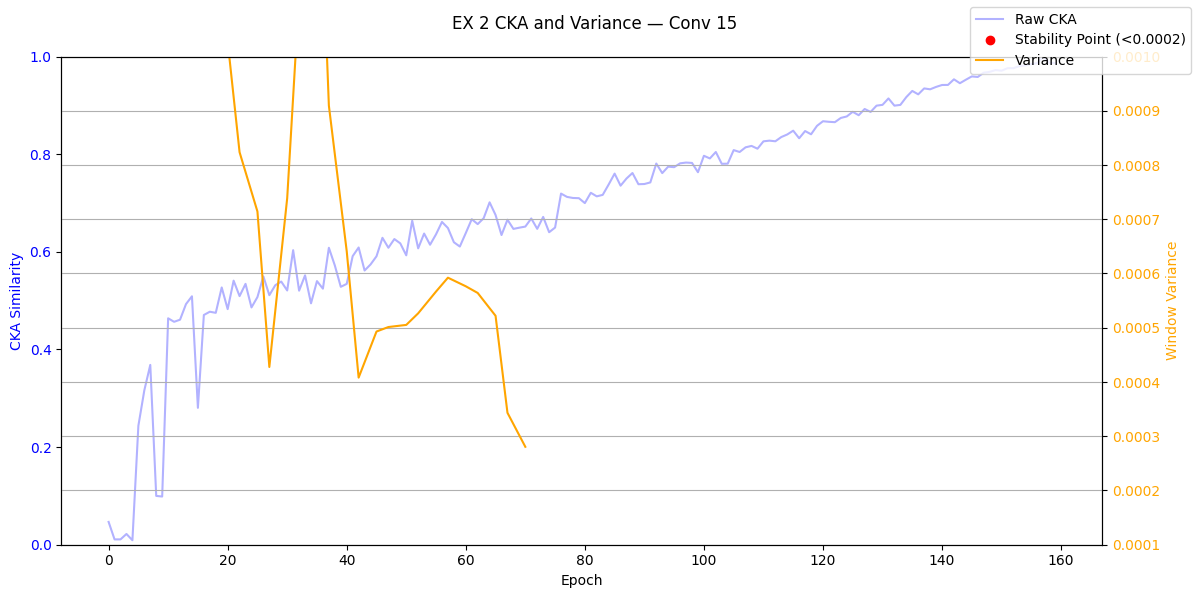

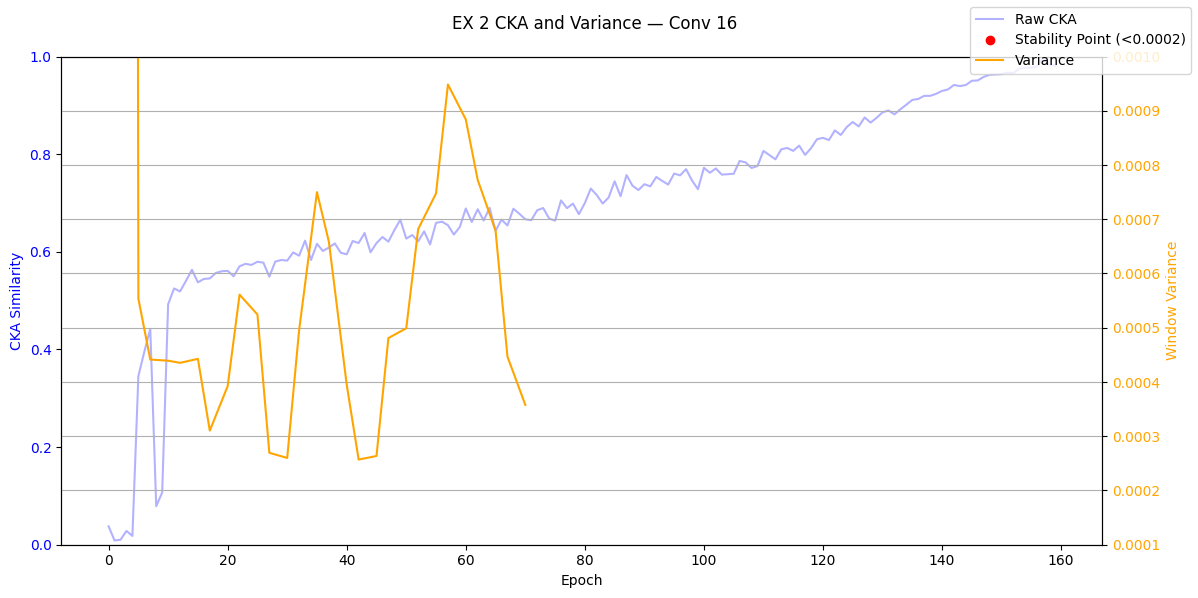

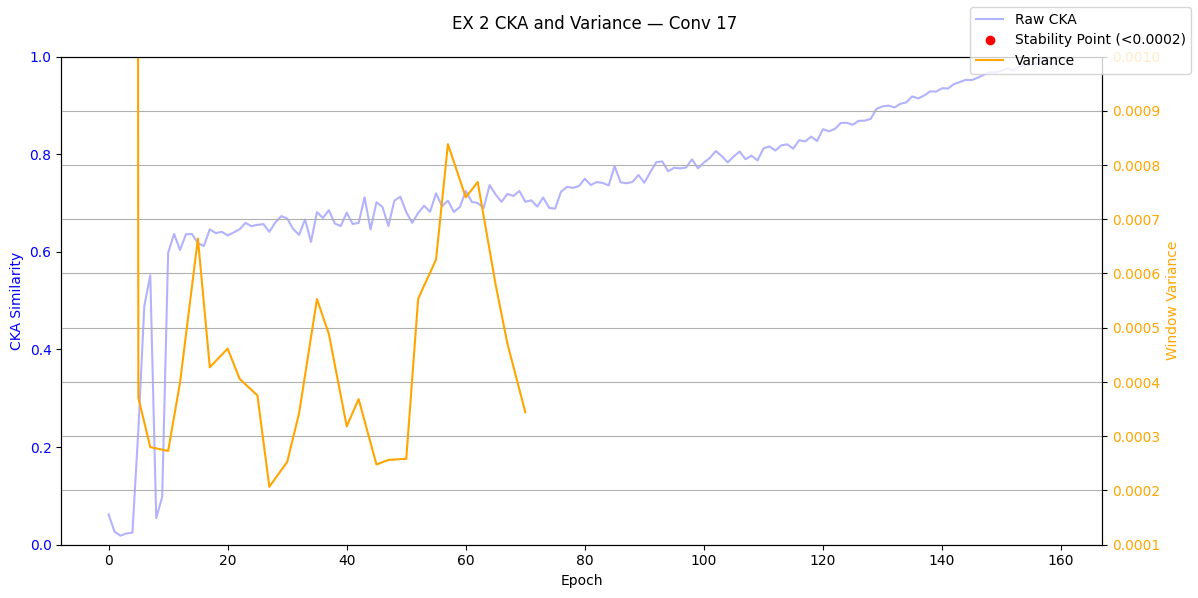

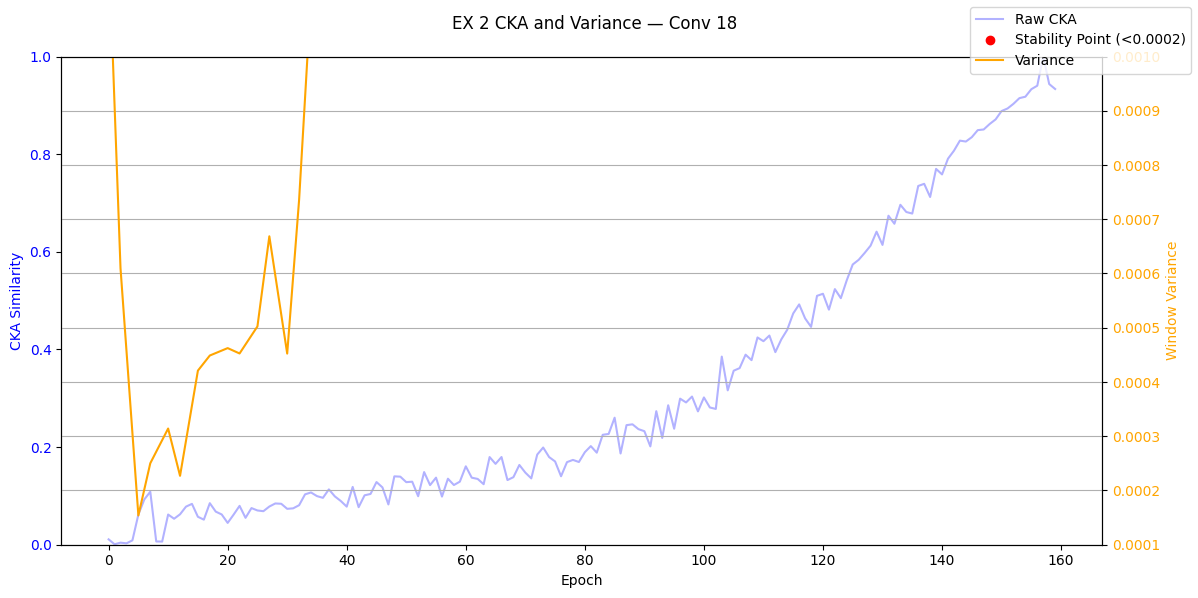

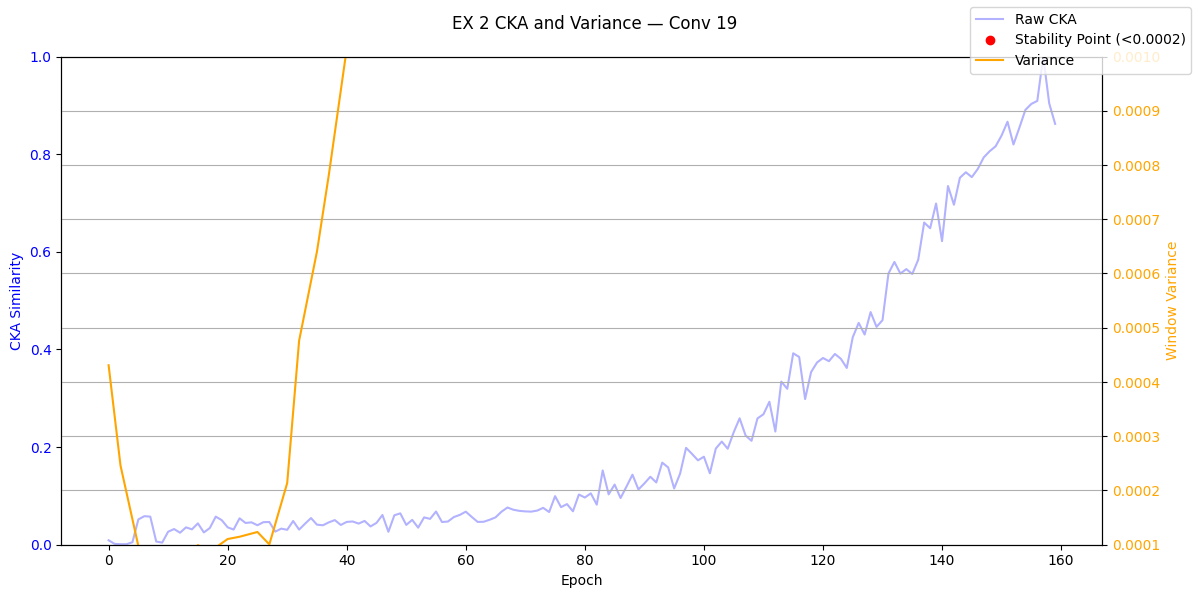

IndexError: index 20 is out of bounds for dimension 1 with size 20

In [15]:
import numpy as np
import matplotlib.pyplot as plt
def get_all_stability_points_for_all_layers(
    all_epochs_matrix, conv_indices, moving_window=20, stride=5, stability_threshold=0.0002, layers=None
):
    if layers is not None:
      cka_freeze_configuration = {layer: [] for layer in layers}
    num_epochs = all_epochs_matrix.shape[0]

    for conv_idx in conv_indices:
        cka_vals = all_epochs_matrix[:, conv_idx]
        if hasattr(cka_vals, 'cpu'):
            cka_vals = cka_vals.cpu().numpy()

        cka_window_values = []
        variance_values = []   # Store variance for plotting
        variance_epochs = []   # Track the center of the window for plotting

        prev_decision_was_frozen = False
        prev_CKA_at_decision_for_frozen = None

        for epoch, cka_val in enumerate(cka_vals):
            cka_window_values.append(cka_val)

            if len(cka_window_values) > moving_window:
                cka_window_values = cka_window_values[stride:]

            if len(cka_window_values) == moving_window:
                window_variance = np.var(cka_window_values, ddof=1)

                center_epoch = (epoch - moving_window + 1) // 2
                start_of_epoch = epoch - moving_window + 1
                # print(f"The Current Epoch: {epoch}, Start of Epoch: {epoch} - {moving_window} = {start_of_epoch}")
                variance_values.append(window_variance)
                variance_epochs.append(center_epoch)
                # After the initial freeze decision, make it so that all labels subsequently are of a frozen layer
                # Doesn't make sense to go back and forth with freezing, measure performance difference after. Weights should change slightly anyway
                if window_variance < stability_threshold and cka_val > 0.3 or cka_freeze_configuration[layers[conv_idx]][-1] == 1:
                    # print(f"Layer {conv_idx} — CKA value when freezing: ", cka_val)
                    # print("Variance of window: ", window_variance)
                    cka_freeze_configuration[layers[conv_idx]].append(1) # 1 for frozen layer
                    cka_freeze_configuration[layers[conv_idx]][-moving_window:] = [1] * moving_window # replace last moving_window elements with 1 for frz
                    prev_decision_was_frozen = True
                    prev_CKA_at_decision_for_frozen = cka_val
                else:
                  cka_freeze_configuration[layers[conv_idx]].append(0) # 0 for non-frozen layer
                  prev_decision_was_frozen = False
                  prev_CKA_at_decision_for_frozen = None
            else:
              if prev_decision_was_frozen:
                # Get percent change, has to be a less than 3% change from the CKA value that was previously frozen at
                prev_cka_value_pct_change = abs(prev_CKA_at_decision_for_frozen - cka_val) / prev_CKA_at_decision_for_frozen
                if prev_cka_value_pct_change < 0.1:
                  cka_freeze_configuration[layers[conv_idx]].append(1) # following previous decision of layer freezing
                else:
                  print("GREATER THAN 3% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER")
                  cka_freeze_configuration[layers[conv_idx]].append(0)
              else:
                cka_freeze_configuration[layers[conv_idx]].append(0) # following previous decision of layer freezing, or there haven't been enough epochs for test

        # Plotting
        fig, ax1 = plt.subplots(figsize=(12, 6))

        ax1.plot(cka_vals, label='Raw CKA', color='blue', alpha=0.3)
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('CKA Similarity', color='blue')
        ax1.tick_params(axis='y', labelcolor='blue')
        ax1.set_ylim(0, 1.0)

        # Plot variance on secondary axis
        ax2 = ax1.twinx()
        ax2.plot(variance_epochs, variance_values, label='Variance', color='orange')
        ax2.set_ylabel('Window Variance', color='orange')
        ax2.set_ylim(0.0001, 0.001)
        ax2.tick_params(axis='y', labelcolor='orange')

        # Plot the first stability marker if found
        frz_moment = [epoch_index for epoch_index, frz_decision in enumerate(cka_freeze_configuration[layers[conv_idx]]) if frz_decision == 1]
        cka_val_at_frz_moment = [cka_vals[epoch_index] for epoch_index in frz_moment]
        if frz_moment is not None:
            ax1.plot(frz_moment, cka_val_at_frz_moment, 'ro', label=f'Stability Point (<{stability_threshold})')

        fig.suptitle(f'EX 2 CKA and Variance — Conv {conv_idx}')
        fig.tight_layout()
        fig.legend(loc='upper right')
        plt.grid(True)
        plt.show()

    if layers is not None:
      return cka_freeze_configuration
with open(f"{experiment_two}/seed_{experiment_two_seed}/cka_freeze_layer_decisions.pkl", "rb") as f:
    cka_freeze_layer_decisions = pickle.load(f)
layers = list(cka_freeze_layer_decisions.keys())
cka_freeze_layer_configuration = get_all_stability_points_for_all_layers(all_epochs_matrix, conv_indices=[i for i in range(number_of_cnn_layers)], layers=layers)

ValueError: x and y must have same first dimension, but have shapes (160,) and (1,)

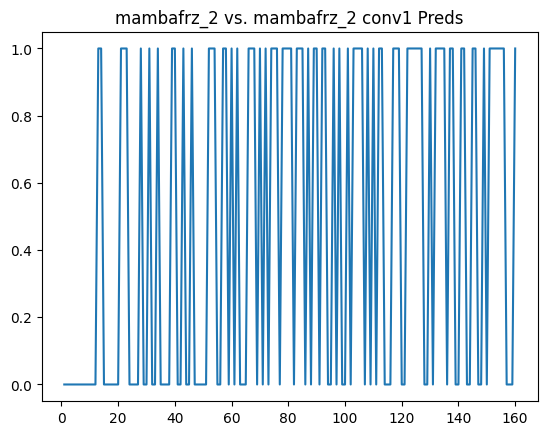

In [16]:
with open(f"{experiment_one}/seed_{experiment_one_seed}/frz_predictor_track_conv_frozen.pkl", "rb") as f:
    track_conv_frozen_frz_pred_experiment_one = pickle.load(f)
with open(f"{experiment_two}/seed_{experiment_two_seed}/frz_predictor_track_conv_frozen.pkl", "rb") as f:
    track_conv_frozen_frz_pred_experiment_two = pickle.load(f)
for layer_index in track_conv_frozen_frz_pred_experiment_one.keys():
    layer_info = track_conv_frozen_frz_pred_experiment_one[layer_index]
    layer_info2 = track_conv_frozen_frz_pred_experiment_two[layer_index]
    layer_name1 = layer_info[0]
    layer_predictions1 = layer_info[1]
    layer_name2 = layer_info2[0]
    layer_predictions2 = layer_info2[1]
    epochs = np.arange(1, len(layer_predictions1) + 1)
    plt.title(f"{experiment_one[:10]} vs. {experiment_two[:10]} {layer_name1} Preds")
    plt.plot(epochs, layer_predictions1, label=f"{experiment_one} Predictions")
    plt.plot(epochs, layer_predictions2, label=f"{experiment_two} Predictions")
    plt.legend()
    plt.show()

In [56]:
# Compare the input weights for each experiment, just to ensure reproducibility
context_window_sizes = [30]
num_epochs = 160
for context_window in context_window_sizes:
    equivalent_tensors = True
    for epoch in range(num_epochs):
        if not equivalent_tensors:
            break
        with open(f"{experiment_one}/smartfrz_input_data/seed_{experiment_one_seed}_{experiment_one_device}/epoch_{epoch}.pkl", "rb") as f:
            layer_input_weights1 = pickle.load(f)
        with open(f"{experiment_two}/smartfrz_input_data/seed_{experiment_two_seed}_{experiment_two_device}/epoch_{epoch}.pkl", "rb") as f:
            layer_input_weights2 = pickle.load(f)
        for layer_name1, layer1_values in layer_input_weights1.items():
            if not equivalent_tensors:
                break
            for layer1_val, layer2_val in zip(layer1_values, layer_input_weights2[layer_name1]):
                if torch.equal(layer1_val, layer2_val):
                    print(f"Equivalent for layer {layer_name1}, epoch {epoch}")
                else:
                    print(f"Not Equivalent for layer {layer_name1}, epoch {epoch}")
                    equivalent_tensors = False
                    break

Equivalent for layer conv1, epoch 0
Equivalent for layer conv1, epoch 0
Equivalent for layer conv1, epoch 0
Equivalent for layer conv1, epoch 0
Equivalent for layer conv1, epoch 0
Equivalent for layer conv1, epoch 0
Equivalent for layer conv1, epoch 0
Equivalent for layer conv1, epoch 0
Equivalent for layer conv1, epoch 0
Equivalent for layer conv1, epoch 0
Equivalent for layer conv1, epoch 0
Equivalent for layer conv1, epoch 0
Equivalent for layer conv1, epoch 0
Equivalent for layer conv1, epoch 0
Equivalent for layer conv1, epoch 0
Equivalent for layer conv1, epoch 0
Equivalent for layer conv1, epoch 0
Equivalent for layer conv1, epoch 0
Equivalent for layer conv1, epoch 0
Equivalent for layer conv1, epoch 0
Equivalent for layer conv1, epoch 0
Equivalent for layer conv1, epoch 0
Equivalent for layer conv1, epoch 0
Equivalent for layer conv1, epoch 0
Equivalent for layer conv1, epoch 0
Equivalent for layer conv1, epoch 0
Equivalent for layer conv1, epoch 0
Equivalent for layer conv1, 

KeyError: 'layer1.0.conv1'

## Compute FLOPs Reduction for this training scheme

In [39]:
# Compute FLOPs associated with each layer
def get_flops(model, inp: Union[torch.Tensor, Tuple], with_backward=False):
    istrain = model.training
    model.eval()

    inp = inp if isinstance(inp, torch.Tensor) else torch.randn(inp)

    flop_counter = FlopCounterMode(model, depth=-1, display=False)
    with flop_counter:
        if with_backward:
            model(inp).sum().backward()
        else:
            model(inp)
    layer_flops = flop_counter.get_total_flops()

    if istrain:
        model.train()
    return layer_flops

In [40]:
# CIFAR10
if dataset == "cifar10":
    num_classes = 10
    num_samples_in_test_set = 50000
elif dataset == "cifar100":
    num_classes = 100
    num_samples_in_test_set = 50000
elif dataset == "imagenet":
    num_classes = 1000
    num_samples_in_test_set = 100000
if model_name == "resnet50":
    model = resnet50(weights=None)
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, num_classes)
elif model_name == "vgg11":
    model = vgg11(weights=None)
    num_features = model.classifier[6].in_features
    model.classifier[6] = nn.Linear(num_features, num_classes)

In [41]:
input = torch.randn(1, 3, 224, 224)
total_flops_one_input = get_flops(model, input)

total_flops_for_training = num_epochs * (3 * total_flops_one_input * num_samples_in_test_set) / (10 ** 12)
print(f"Full Training: {int(total_flops_for_training)} TFLOPs")

Full Training: 196192 TFLOPs


/tmp/ipykernel_1313802/3474023913.py:8: UserWarning: mods argument is not needed anymore, you can stop passing it
  flop_counter = FlopCounterMode(model, depth=-1, display=False)


In [42]:
def add_flops_hook(layer_flops):
    def hook(module, input, output):
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            output_shape = output.shape
            if isinstance(module, nn.Conv2d):
                kernel_height, kernel_width = module.kernel_size
                input_channels = module.in_channels
                output_channels = module.out_channels
                output_height, output_width = output_shape[2], output_shape[3]
                flops = (2 * kernel_height * kernel_width * input_channels) * output_channels * output_height * output_width
            elif isinstance(module, nn.Linear):
                input_features = module.in_features
                output_features = module.out_features
                flops = 2 * input_features * output_features
            else:
                flops = 0
                raise ValueError("Should only be looking at FLOPs for FC and Conv!")
            layer_flops[id(module)] = layer_flops.get(id(module), 0) + flops
    return hook
def get_flops(model, inp: Union[torch.Tensor], with_backward=False):
    istrain = model.training
    model.train()

    inp = inp if isinstance(inp, torch.Tensor) else torch.randn(inp)

    layer_flops = {}
    hooks = []
    for name, module in model.named_modules():
        if is_cnn_layer(module):
            hooks.append(module.register_forward_hook(add_flops_hook(layer_flops)))

    # Forward pass
    output = model(inp)

    if with_backward:
        output.sum().backward()

    # Remove hooks
    for hook in hooks:
        hook.remove()

    # Map layer names to FLOPs
    named_flops = {}
    for name, module in model.named_modules():
        if is_cnn_layer(module):
            named_flops[name] = layer_flops.get(id(module), 0)
    # Restore training state
    if istrain:
        model.train()

    return named_flops

In [43]:
layer_flops = get_flops(model, input)
conv_and_fc_flops_dict = {}
for layer, flops in layer_flops.items():
    conv_and_fc_flops_dict[layer] = flops
print(f"Number of layers for computed FLOPs: {len(conv_and_fc_flops_dict.keys())}")

Number of layers for computed FLOPs: 53


In [44]:
conv_and_fc_flops_dict.keys()

dict_keys(['conv1', 'layer1.0.conv1', 'layer1.0.conv2', 'layer1.0.conv3', 'layer1.0.downsample.0', 'layer1.1.conv1', 'layer1.1.conv2', 'layer1.1.conv3', 'layer1.2.conv1', 'layer1.2.conv2', 'layer1.2.conv3', 'layer2.0.conv1', 'layer2.0.conv2', 'layer2.0.conv3', 'layer2.0.downsample.0', 'layer2.1.conv1', 'layer2.1.conv2', 'layer2.1.conv3', 'layer2.2.conv1', 'layer2.2.conv2', 'layer2.2.conv3', 'layer2.3.conv1', 'layer2.3.conv2', 'layer2.3.conv3', 'layer3.0.conv1', 'layer3.0.conv2', 'layer3.0.conv3', 'layer3.0.downsample.0', 'layer3.1.conv1', 'layer3.1.conv2', 'layer3.1.conv3', 'layer3.2.conv1', 'layer3.2.conv2', 'layer3.2.conv3', 'layer3.3.conv1', 'layer3.3.conv2', 'layer3.3.conv3', 'layer3.4.conv1', 'layer3.4.conv2', 'layer3.4.conv3', 'layer3.5.conv1', 'layer3.5.conv2', 'layer3.5.conv3', 'layer4.0.conv1', 'layer4.0.conv2', 'layer4.0.conv3', 'layer4.0.downsample.0', 'layer4.1.conv1', 'layer4.1.conv2', 'layer4.1.conv3', 'layer4.2.conv1', 'layer4.2.conv2', 'layer4.2.conv3'])

In [45]:
##############################################
#### ONLY FOR SIMILARITY_GUIDED_TRAINING #####
##############################################
with open(f"{experiment_two}/seed_{experiment_two_seed}/resnet50_cka_freeze_configuration.pkl", "rb") as f:
    cka_freeze_layer_configuration = pickle.load(f)
total_flops_for_training = num_epochs * (3 * total_flops_one_input * num_samples_in_test_set)
for epoch in range(num_epochs):
    # Flag for determining if the previous layer was frozen
    is_previous_layer_frozen = True
    for current_layer, epoch_val_frozen in cka_freeze_layer_configuration.items():
        # print(f"Epoch frozen for layer {epoch_frozen[0]}, {epoch_val_frozen}")
        if epoch_val_frozen == -1:
            print("NEVER FROZEN", current_layer)
            is_previous_layer_frozen = False
        elif epoch >= epoch_val_frozen:
            # Freeze layer weight updates
            # print(current_layer_index)
            total_flops_for_training -= (conv_and_fc_flops_dict[current_layer] * num_samples_in_test_set)

            if is_previous_layer_frozen:
                # Remove Backpropagating Activations
                total_flops_for_training -= (conv_and_fc_flops_dict[current_layer] * num_samples_in_test_set)

            is_previous_layer_frozen = True
        else:
            is_previous_layer_frozen = False
            break
print(f"Total FLOPs with Freeze Configuration: {total_flops_for_training / (10 ** 12)} TFLOPs")

NEVER FROZEN layer2.3.conv3
NEVER FROZEN layer3.0.conv1
NEVER FROZEN layer3.0.conv2
NEVER FROZEN layer3.0.conv3
NEVER FROZEN layer3.0.downsample.0
NEVER FROZEN layer3.1.conv1
NEVER FROZEN layer3.1.conv2
NEVER FROZEN layer3.1.conv3
NEVER FROZEN layer3.2.conv1
NEVER FROZEN layer3.2.conv2
NEVER FROZEN layer3.2.conv3
NEVER FROZEN layer3.3.conv1
NEVER FROZEN layer3.3.conv2
NEVER FROZEN layer3.3.conv3
NEVER FROZEN layer3.4.conv1
NEVER FROZEN layer3.4.conv2
NEVER FROZEN layer3.4.conv3
NEVER FROZEN layer3.5.conv1
NEVER FROZEN layer3.5.conv2
NEVER FROZEN layer3.5.conv3
NEVER FROZEN layer4.0.conv1
NEVER FROZEN layer4.0.conv2
NEVER FROZEN layer4.0.conv3
NEVER FROZEN layer4.0.downsample.0
NEVER FROZEN layer4.1.conv1
NEVER FROZEN layer4.1.conv2
NEVER FROZEN layer4.1.conv3
NEVER FROZEN layer4.2.conv1
NEVER FROZEN layer4.2.conv2
NEVER FROZEN layer4.2.conv3
Total FLOPs with Freeze Configuration: 195839.934464 TFLOPs


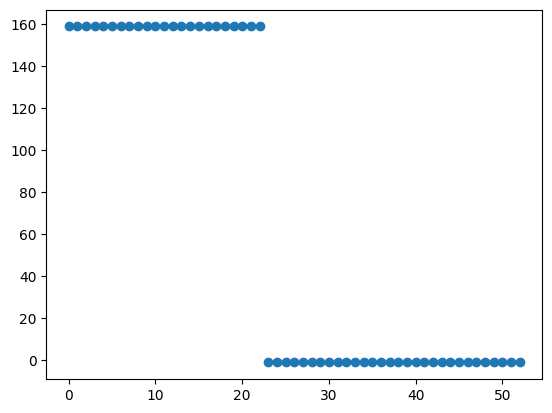

In [46]:
epochs_frozen = list([val for val in cka_freeze_layer_configuration.values()])
conv_indices = list(range(len(epochs_frozen)))
plt.scatter(conv_indices, epochs_frozen)
plt.show()

In [47]:
with open(f"{experiment_two}/seed_{experiment_two_seed}/frz_predictor_track_conv_frozen.pkl", "rb") as f:
    cka_freeze_layer_configuration = pickle.load(f)
total_flops_for_training = num_epochs * (3 * total_flops_one_input * num_samples_in_test_set)
for epoch in range(num_epochs):
    # Flag for determining if the previous layer was frozen
    is_previous_layer_frozen = False
    for current_layer_index, epoch_frozen in cka_freeze_layer_configuration.items():
        try:
            epoch_val_frozen = epoch_frozen[1].index(1)
        except ValueError:
            epoch_val_frozen = -1
        # print(f"Epoch frozen for layer {epoch_frozen[0]}, {epoch_val_frozen}")
        if epoch_val_frozen == -1:
            is_previous_layer_frozen = False
            break # current linear restriction means once a layer is not frozen, we don't take away for that epoch
        elif epoch >= epoch_val_frozen:
            # Freeze layer weight updates
            # print(current_layer_index)
            total_flops_for_training -= (conv_and_fc_flops_dict[epoch_frozen[0]] * num_samples_in_test_set)

            if is_previous_layer_frozen:
                # Remove Backpropagating Activations
                total_flops_for_training -= (conv_and_fc_flops_dict[epoch_frozen[0]] * num_samples_in_test_set)

            is_previous_layer_frozen = True
        else:
            is_previous_layer_frozen = False
            break
print(f"Total FLOPs with Freeze Configuration: {total_flops_for_training / (10 ** 12)} TFLOPs")

Total FLOPs with Freeze Configuration: 177933.8461184 TFLOPs


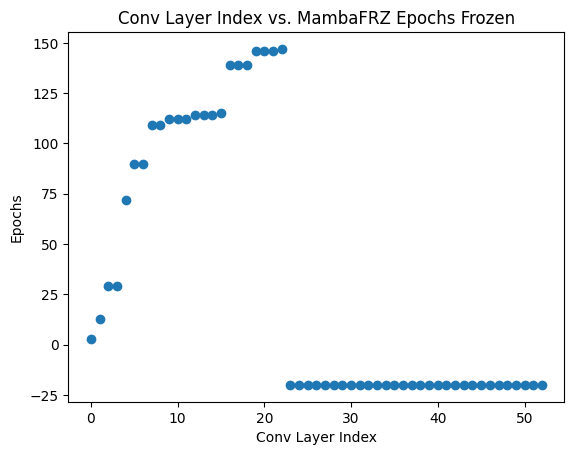

In [48]:
layers = list(range(53))
epochs_frozen = []
for current_layer_index, epoch_frozen in cka_freeze_layer_configuration.items():
    try:
        epochs_frozen.append(epoch_frozen[1].index(1))
    except ValueError:
        epochs_frozen.append(-20)
plt.scatter(layers, epochs_frozen)
plt.title("Conv Layer Index vs. MambaFRZ Epochs Frozen")
plt.ylabel("Epochs")
plt.xlabel("Conv Layer Index")
plt.show()

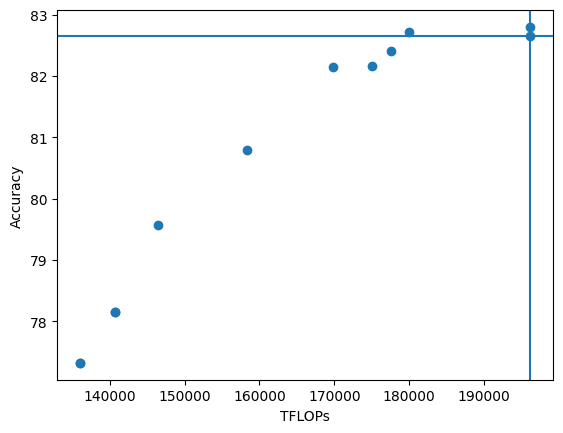

In [85]:
# Plot relationship between TFLOPs and accuracy
acc_tflops = [(135983, 77.32), (140722, 78.15), (177512, 82.41), (180000, 82.72), (196192, 82.66), (196192, 82.8), (135983, 77.32), (140722, 78.15), (169771, 82.14), (146455, 79.57),(158333, 80.789), (175018, 82.17)]
tflops = [item[0] for item in acc_tflops]
acc = [item[1] for item in acc_tflops]
plt.scatter(tflops, acc)
plt.axhline(82.66)
plt.axvline(196192)
plt.ylabel("Accuracy")
plt.xlabel("TFLOPs")
plt.show()